In [ ]:
from gender_association_method import associate_gender
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.font_manager import FontProperties
from metrics import subset_representation_bias_score
from nltk.corpus import names
from scipy.spatial import distance
from scipy.stats import ttest_ind
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from statistics import stdev
from textwrap import wrap
from utils import compute_calibrated_marked_words

import gensim
import matplotlib.pyplot as plt
import matplotlib.cm as cm 
import nltk
import numpy as np
import pandas as pd
import pickle

### Load generated personas and biographies from GPT-3.5, GPT-4o-mini, and Llama-3.1-70b

In [2]:
df_inferred_gender_gpt4 = pd.read_csv('data/gpt-4o-mini/generated_personas_occupation_inferred_gender_gpt-4o-mini-2024-07-18_100_12-03-2024, 15:29:10.csv')
                                    
df_gender_gpt4 = pd.read_csv('data/gpt-4o-mini/generated_personas_occupation_from_winogender_gender_gpt-4o-mini-2024-07-18_100_11-11-2024, 12:02:49.csv')

df_inferred_gender_gpt3_5 = pd.read_csv('data/gpt-3.5/generated_personas_occupation_inferred_gender_gpt-3.5-turbo-0125_100_12-06-2024, 20:25:04.csv')
df_gender_gpt3_5 = pd.read_csv('data/gpt-3.5/generated_personas_occupation_from_winogender_gender_gpt-3.5-turbo-0125_100_11-12-2024, 08:10:32.csv')

df_gender_llama3 = pd.read_csv('data/llama-3.1-70b/generated_personas_occupation_from_winogender_gender_meta-llama-Meta-Llama-3.1-70B-Instruct-Turbo_100_11-23-2024, 09:50:14.csv')
df_inferred_gender_llama3 = pd.read_csv('data/llama-3.1-70b/generated_personas_occupation_inferred_gender_meta-llama-Meta-Llama-3.1-70B-Instruct-Turbo_100_11-27-2024, 14:04:28.csv')

df_no_dem_gpt4 = pd.read_csv('data/gpt-4o-mini/generated_personas_occupation_no_demographics_gpt-4o-mini-2024-07-18_100_12-06-2024, 16:21:41.csv')
df_no_dem_gpt3 = pd.read_csv('data/gpt-3.5/generated_personas_occupation_no_demographics_gpt-3.5-turbo-0125_100_08-11-2024, 04:22:20.csv')
df_no_dem_llama3 = pd.read_csv('data/llama-3.1-70b/generated_personas_occupation_no_demographics_meta-llama-Meta-Llama-3.1-70B-Instruct-Turbo_100_11-21-2024, 07:28:21.csv')



In [3]:
gpt4_name = 'gpt-4o-mini-2024-07-18'
gpt3_5_name = 'gpt-3.5-turbo-0125'
llama3_name = 'LLama-3.1-70b'

In [4]:
def get_occupations_inferred_gender(df, num_gens=100):
    _occupations = df['occupation'].unique()
    occupations = list()
    for occupation in _occupations:
        occ_df = df[df['occupation'] == occupation]
        templates = occ_df['prompt'].unique()
        include_occ = True
        for template in templates:
            template_df = occ_df[occ_df['prompt'] == template]
            for pronoun in ['M', 'F']:
                temp_df = template_df[template_df['inferred_gender'] == pronoun]
                if len(temp_df) < num_gens:
                    include_occ = False
                    break
            if include_occ == False:
                break
        if include_occ:
            occupations.append(occupation)
    return occupations

In [5]:
occupations_gpt4 = get_occupations_inferred_gender(df_inferred_gender_gpt4)
print('gpt-4o-mini occupations:', occupations_gpt4)

gpt-4o-mini occupations: ['technician', 'accountant', 'supervisor', 'engineer', 'worker', 'clerk', 'inspector', 'manager', 'administrator', 'salesperson', 'advisor', 'investigator', 'bartender', 'officer', 'teacher', 'lawyer', 'planner', 'paramedic', 'appraiser', 'architect', 'programmer', 'dispatcher', 'auditor', 'broker', 'chef', 'firefighter', 'software engineer', 'cook', 'pilot']


In [6]:
occupations_gpt3_5 = get_occupations_inferred_gender(df_inferred_gender_gpt3_5)
print('gpt-3.5-turbo-0125 occupations:', occupations_gpt3_5)

gpt-3.5-turbo-0125 occupations: ['technician', 'accountant', 'supervisor', 'engineer', 'worker', 'clerk', 'inspector', 'manager', 'administrator', 'salesperson', 'advisor', 'janitor', 'investigator', 'bartender', 'officer', 'instructor', 'surgeon', 'paramedic', 'examiner', 'chemist', 'architect', 'baker', 'programmer', 'painter', 'broker', 'chef', 'firefighter', 'software engineer', 'cook', 'pilot']


In [7]:
occupations_llama3 = get_occupations_inferred_gender(df_inferred_gender_llama3)
print('llama-3.1-70b', occupations_llama3)

llama-3.1-70b ['technician', 'accountant', 'supervisor', 'engineer', 'worker', 'inspector', 'manager', 'salesperson', 'advisor', 'janitor', 'investigator', 'bartender', 'officer', 'lawyer', 'surgeon', 'paramedic', 'appraiser', 'architect', 'programmer', 'painter', 'chef', 'firefighter', 'software engineer', 'cook', 'pilot', 'examiner', 'auditor', 'broker']


In [8]:
def get_balanced_df(df, occupations, gender_name='inferred_gender', num_gens=100):
    balanced_inferred_gender = pd.DataFrame()
    for occupation in occupations:
        occ_df = df[df['occupation'] == occupation]
        templates = occ_df['prompt'].unique()
        for template in templates:
            template_df = occ_df[occ_df['prompt'] == template]
            for pronoun in ['M', 'F']:
                temp_df = template_df[template_df[gender_name] == pronoun]
                pronoun_df = temp_df.sample(n=num_gens, random_state=42)
                balanced_inferred_gender = pd.concat([balanced_inferred_gender, pronoun_df], axis=0)
    return balanced_inferred_gender

In [9]:
balanced_inferred_gender_gpt4 = get_balanced_df(df_inferred_gender_gpt4, occupations_gpt4)

In [10]:
balanced_inferred_gender_gpt3_5 = get_balanced_df(df_inferred_gender_gpt3_5, occupations_gpt3_5)

In [11]:
balanced_inferred_gender_llama3 = get_balanced_df(df_inferred_gender_llama3, occupations_llama3)

In [13]:
# load in names to exclude from returned calibrated marked words
names_from_csv = pd.read_csv('names_with_dem.csv')

first_names = list()
last_names = list()

for name in names_from_csv['First Name'].unique():
    if type(name) == str:
        first_names.append(name.lower())
for name in names_from_csv['Last Name'].unique():
    if type(name) == str:
        last_names.append(name.lower())

lower_names = set(first_names + last_names)

# Identify calibrated marked words for each associated and specified gender per model

In [15]:
dv3_mw_inferred_gender_gpt4, dv3_mw_names_inferred_gender_gpt4, dv3_mw_by_occ_inferred_gender_gpt4, dv3_mw_by_occ_names_inferred_gender_gpt4, dv3_mw_occ_inferred_gender_gpt4, dv3_mw_occ_names_inferred_gender_gpt4 = compute_calibrated_marked_words(balanced_inferred_gender_gpt4, occupations_gpt4, lower_names=lower_names, print_words=True)

{'M': [[[]], ['his', 'he', 'him', 'unsung', 'marco', 'volunteers', 'students', 'hero', 'schools', 'leo', 'emerging', 'education', 'knowledge', 'minds', 'certifications', 'computers', 'himself', 'involvement', 'teaching', 'streamlined', 'learning', 'technicians', 'philosophy', 'profound', 'lifelong', 'advancement', 'forefront', 'nurturing', 'aspirations'], [[]], ['his', 'he', 'him', 'children', 'himself', 'devoted', 'wife', 'charles', 'sweetheart', 'principles', 't', 'son', 'family', 'technology', 'everevolving', 'outdoor', 'math', 'architect', 'ben', 'respected', 'r', 'urbanachampaign', 'lucas', 'approach', 'foundation', 'h', 'pivotal', 'advocates', 'boutique', 'married', 'thorne', 'graphic', 'expanding', 'ranging'], [[]], ['his', 'he', 'him', 'male', 'safety', 'manufacturing', 'warehouse', 'handson', 'woodworking', 'gender', 'employees', 'logistics', 'himself', 'protocols', 'manager', 'soccer', 'caldwell', 'volunteered', 'ensure', 'loyalty', 'factory', 'basketball', 'industries', 'oft

In [16]:
dv3_mw_inferred_gender_gpt3_5, dv3_mw_names_inferred_gender_gpt3_5, dv3_mw_by_occ_inferred_gender_gpt3_5, dv3_mw_by_occ_names_inferred_gender_gpt3_5, dv3_mw_occ_inferred_gender_gpt3_5, dv3_mw_occ_names_inferred_gender_gpt3_5 = compute_calibrated_marked_words(balanced_inferred_gender_gpt3_5, occupations_gpt3_5, lower_names=lower_names, print_words=True)

{'M': [[[]], ['his', 'he', 'male', 'electronics', 'tinkering', 'associates', 'building', 'gadgets', 'fixing', 'mechanical', 'highquality', 'camping', 'goto', 'deliver', 'striving', 'games', 'video', 'playing', 'him', 'customerfocused', 'gender'], [[]], ['his', 'him', 'he', 'himself', 'husband', 'master', 'father', 'analyze', 'endure', 'legacy', 'terry'], [[]], ['his', 'him', 'he', 'steadfast', 'empower', 'showcasing', 'supervisors', 'respected', 'handson'], [[]], ['his', 'he', 'tinkering', 'male', 'enthusiast', 'him', 'playing', 'gadgets', 'garage', 'improving', 'angeles', 'los'], [[]], ['his', 'he', 'him', 'construction', 'craft', 'himself', 'projects', 'skilled', 'father', 'reputation', 'husband', 'setbacks', 'laborer', 'craftsmanship', 'odd', 'skills', 'homes', 'buildings', 'talent', 'reliable', 'humble', 'learning', 'carpenter', 'carpentry', 'jobs', 'peers', 'footsteps', 'building', 'quality', 'detail', 'reliability', 'tackle', 'residential', 'workforce', 'family', 'apprentice', 'f

In [17]:
dv3_mw_inferred_gender_llama3, dv3_mw_names_inferred_gender_llama3, dv3_mw_by_occ_inferred_gender_llama3, dv3_mw_by_occ_names_inferred_gender_llama3, dv3_mw_occ_inferred_gender_llama3, dv3_mw_occ_names_inferred_gender_llama3 = compute_calibrated_marked_words(balanced_inferred_gender_llama3, occupations_llama3, lower_names=lower_names, print_words=True)

{'M': [[[]], ['his', 'him', 'he', 'fixer', 'affectionately', 'clients', 'himself', 'master', 'suburban', 'remains', 'reputation', 'troubleshooter', 'whiz', 'loyal', 'nickname', 'tinkering', 'businesses', 'humble', 'among', 'problemsolver', 'unsung', 'uncanny', 'hero', 'simple', 'lend', 'rob', 'husband', 'corporations', 'combined', 'hawk', 'most', 'custom', 'intractable', 'helping', 'repair', 'grounded', 'online', 'unassuming', 'demeanor', 'share', 'devoted'], [[]], ['his', 'him', 'he', 'himself', 'edward', 'numbers', 'father', 'poring', 'husband', 'intricate', 'concise', 'spent', 'affectionately', 'hugh', 'guru', 'doe', 'd', 'fascinated', 'charities', 'donald', 'precision', 'peers', 'professionalism', 'cruncher', 'seasoned', 'emmett', 'professors', 'statements'], [[]], ['his', 'he', 'him', 'resultant', 'manufacturing', 'himself', 'guidance', 'unshakeable', 'affectionately', 'salary', 'unprecedented', 'uneven', 'exposure', 'intimacy', 'ted', 'declined', 'climbing', 'disclosed', 'emmett'

In [18]:
def get_balanced_df_gender(df_balanced_inferred_gender, df_gender):
    balanced_inferred_gender_occupations = df_balanced_inferred_gender['occupation'].unique()
    balanced_df_all_genders = df_gender[df_gender['occupation'].isin(balanced_inferred_gender_occupations)]
    balanced_df_gender = balanced_df_all_genders[balanced_df_all_genders['gender'].isin(['M', 'F'])]
    return balanced_df_gender


In [19]:
balanced_df_gender_gpt4 = get_balanced_df_gender(balanced_inferred_gender_gpt4, df_gender_gpt4)

In [20]:
balanced_df_gender_gpt3_5 = get_balanced_df_gender(balanced_inferred_gender_gpt3_5, df_gender_gpt3_5)

In [21]:
balanced_df_gender_llama3 = get_balanced_df_gender(balanced_inferred_gender_llama3, df_gender_llama3)


In [22]:
dv3_mw_gender_gpt4, dv3_mw_names_gender_gpt4, dv3_mw_by_occ_gender_gpt4, dv3_mw_by_occ_names_gender_gpt4, dv3_mw_occ_gender_gpt4, dv3_mw_occ_names_gender_gpt4 = compute_calibrated_marked_words(balanced_df_gender_gpt4, occupations_gpt4, inferred_gender=False, lower_names=lower_names, print_words=True)

{'F': [[['her', 'she', 'women', 'energy', 'stem', 'girls', 'dr', 'renewable', 'engineering', 'diversity', 'careers', 'female', 'advocate', 'california', 'barriers', 'pursue', 'solar', 'science', 'young', 'inclusive', 'environmental', 'mentorship', 'empowering', 'conferences', 'resilience', 'pioneering', 'organizations', 'sustainable', 'determination', 'maledominated', 'representation', 'focused', 'promote', 'outreach', 'actively', 'advocating', 'san', 'break', 'advocacy', 'diverse', 'aimed', 'leadership', 'bachelors', 'inspire', 'passionate', 'technology', 'panel', 'initiatives', 'programs', 'faced', 'encouraging', 'field', 'phd', 'university', 'engineers', 'pursuing', 'vibrant', 'interested', 'herself', 'industry', 'inclusion', 'berkeley', 'generations', 'nonprofit', 'create', 'speaker', 'founded', 'undergraduate', 'predominantly', 'inclusivity', 'leading', 'stanford', 'shes', 'supportive', 'future', 'encourage', 'empathetic', 'proving', 'enter', 'gender', 'woman', 'mexico', 'award', 

In [23]:
dv3_mw_gender_gpt3_5, dv3_mw_names_gender_gpt3_5, dv3_mw_by_occ_gender_gpt3_5, dv3_mw_by_occ_names_gender_gpt3_5, dv3_mw_occ_gender_gpt3_5, dv3_mw_occ_names_gender_gpt3_5 = compute_calibrated_marked_words(balanced_df_gender_gpt3_5, occupations_gpt3_5, inferred_gender=False, lower_names=lower_names, print_words=True)

{'F': [[['her', 'she', 'women', 'stem', 'careers', 'tech', 'industry', 'maledominated', 'facing', 'determination', 'barriers', 'herself', 'inspire', 'woman', 'diversity', 'female', 'pursue', 'interested', 'advocate', 'break', 'confident', 'model', 'gender', 'inclusion', 'stereotypes', 'perseverance', 'breaking', 'serves', 'girls', 'young', 'role', 'discrimination', 'promoting', 'inspiring', 'prestigious', 'pursuing', 'boundaries', 'skepticism', 'alice', 'challenges', 'actively', 'proving', 'science', 'generations', 'innovative', 'aspiring', 'engineering', 'passionate', 'obstacles', 'pioneering', 'despite', 'empower', 'trailblazing', 'landed', 'biography', 'peers', 'way', 'footsteps', 'passions', 'university', 'engineers', 'recognition', 'follow', 'generation', 'shattered', 'equality', 'expectations', 'excelled', 'cuttingedge', 'never', 'technicians', 'hard', 'other', 'growing', 'everywhere', 'paving', 'accomplishments', 'prove', 'world', 'barrier', 'inspiration', 'excel', 'novels', 'nu

In [24]:
dv3_mw_gender_llama3, dv3_mw_names_gender_llama3, dv3_mw_by_occ_gender_llama3, dv3_mw_by_occ_names_gender_llama3, dv3_mw_occ_gender_llama3, dv3_mw_occ_names_gender_llama3 = compute_calibrated_marked_words(balanced_df_gender_llama3, occupations_llama3, inferred_gender=False, lower_names=lower_names, print_words=True)

{'F': [[['her', 'she', 'women', 'tech', 'stem', 'herself', 'careers', 'shes', 'female', 'lexi', 'pursue', 'california', 'technology', 'woman', 'maledominated', 'diversity', 'alexandra', 'girls', 'prestigious', 'advocate', 'inclusion', 'san', 'promoting', 'industry', 'confident', 'empowering', 'curly', 'young', 'trailblazing', 'engineers', 'inspiring', 'coding', 'mentoring', 'accomplished', 'awards', 'stereotypes', 'mathematics', 'science', 'tattoos', 'internship', 'engineering', 'award', 'model', 'determination', 'shining', 'encouraged', 'volunteering', 'inspire', 'yoga', 'clothing', 'passionate', 'evie', 'mentorship', 'hazel', 'inspiration', 'practicing', 'recognition', 'fiercely', 'underrepresented', 'fulltime', 'barriers', 'perseverance', 'testament', 'climbing', 'biases', 'journey', 'serves', 'colorful', 'expressive', 'pioneering', 'inspired', 'accolades', 'coveted', 'traditionally', 'actively', 'stanford', 'education', 'achievements', 'berkeley', 'prowess', 'top', 'programs', 'out

#### Identifies the set of words across models identified as statistically significant using the calibrated marked words method for each associated gender and model pair to build the vector space using Word2Vec (i.e. `word_model`). This will be used in the computation of the Subset Representational Bias Score.

In [ ]:
def add_to_word_list(word_list, dv3_mw_gender, dv3_mw_inferred_gender, occ):
    for pronoun in ['F', 'M']:
        word_list.append(dv3_mw_gender[occ][pronoun])
        word_list.append(dv3_mw_inferred_gender[occ][pronoun])

word_list = list()
for occ in dv3_mw_by_occ_inferred_gender_gpt4.keys():
    add_to_word_list(word_list, dv3_mw_by_occ_gender_gpt4, dv3_mw_by_occ_inferred_gender_gpt4, occ)
for occ in dv3_mw_by_occ_inferred_gender_gpt3_5.keys():
    add_to_word_list(word_list, dv3_mw_by_occ_gender_gpt3_5, dv3_mw_by_occ_inferred_gender_gpt3_5, occ)
for occ in dv3_mw_by_occ_inferred_gender_llama3.keys():
    add_to_word_list(word_list, dv3_mw_by_occ_gender_llama3, dv3_mw_by_occ_inferred_gender_llama3, occ)
word_model = gensim.models.Word2Vec(sentences=word_list, min_count=1, vector_size=100, window=5)
print(word_list)

[['her', 'she', 'women', 'energy', 'stem', 'girls', 'dr', 'renewable', 'engineering', 'diversity', 'careers', 'female', 'advocate', 'california', 'barriers', 'pursue', 'solar', 'science', 'young', 'inclusive', 'environmental', 'mentorship', 'empowering', 'conferences', 'resilience', 'pioneering', 'organizations', 'sustainable', 'determination', 'maledominated', 'representation', 'focused', 'promote', 'outreach', 'actively', 'advocating', 'san', 'break', 'advocacy', 'diverse', 'aimed', 'leadership', 'bachelors', 'inspire', 'passionate', 'technology', 'panel', 'initiatives', 'programs', 'faced', 'encouraging', 'field', 'phd', 'university', 'engineers', 'pursuing', 'vibrant', 'interested', 'herself', 'industry', 'inclusion', 'berkeley', 'generations', 'nonprofit', 'create', 'speaker', 'founded', 'undergraduate', 'predominantly', 'inclusivity', 'leading', 'stanford', 'shes', 'supportive', 'future', 'encourage', 'empathetic', 'proving', 'enter', 'gender', 'woman', 'mexico', 'award', 'mit', 

In [26]:
canidate_sets = {gpt4_name: dv3_mw_by_occ_inferred_gender_gpt4, gpt3_5_name: dv3_mw_by_occ_inferred_gender_gpt3_5, llama3_name: dv3_mw_by_occ_inferred_gender_llama3}

target_sets = {gpt4_name: dv3_mw_by_occ_gender_gpt4, gpt3_5_name: dv3_mw_by_occ_gender_gpt3_5, llama3_name: dv3_mw_by_occ_gender_llama3}

In [27]:
def compute_subset_representational_bias_scores(exclude_pronouns=True,
pronouns_to_exclude=['she', 'he', 'they', 'them', 'hers', 'his', 'their', 'theirs']):
    canidate_sets = {gpt4_name: dv3_mw_by_occ_inferred_gender_gpt4, gpt3_5_name: dv3_mw_by_occ_inferred_gender_gpt3_5, llama3_name: dv3_mw_by_occ_inferred_gender_llama3}

    target_sets = {gpt4_name: dv3_mw_by_occ_gender_gpt4, gpt3_5_name: dv3_mw_by_occ_gender_gpt3_5, llama3_name: dv3_mw_by_occ_gender_llama3}
    representational_bias_scores = dict()
    for model in canidate_sets.keys():
        representational_bias_scores[model] = dict()
        for occupation in canidate_sets[model].keys():
            representational_bias_scores[model][occupation] = dict()
            for g in ['F', 'M']:
                representational_bias_scores[model][occupation][g] = subset_representation_bias_score(canidate_sets[model][occupation][g], target_sets[model][occupation]['F'], target_sets[model][occupation]['M'], word_model, exclude_words=exclude_pronouns, words_to_exclude=pronouns_to_exclude)
    return representational_bias_scores
representational_bias_scores = compute_subset_representational_bias_scores()

In [28]:
# prints the Subset Representation Bias Score (SRBS) per model and occupation pair. SRBS(IF||F,M) refers to the SRBS for associated women and SRBS(IM||F,M) refers to the SRBS for associated men.
print('Occupation & Model & SRBS(IF||F,M)  & SRBS(IM||F,M)\\\\')
print('\\hline')
iff_ifm = {gpt4_name: list(), gpt3_5_name: list(), llama3_name: list()}
imf_imm = {gpt4_name: list(), gpt3_5_name: list(), llama3_name: list()}
all_occupations = set()
for model in representational_bias_scores.keys():
    for occ in representational_bias_scores[model].keys():
        all_occupations.add(occ)

for occupation in all_occupations:
    str_to_print = f'{occupation}'
    for model in representational_bias_scores.keys():
        if occupation in representational_bias_scores[model]:
            model_name = model[0:model.index('-')+1+model[model.index('-')+1:].index('-')]
            str_to_print += f" & {model_name} & {representational_bias_scores[model][occupation]['F']:.2f} & {representational_bias_scores[model][occupation]['M']:.2f}\\\\\n"
        else:
            str_to_print += ' & & & \\\\\n'
    print(str_to_print[0:len(str_to_print)-1])


Occupation & Model & SRBS(IF||F,M)  & SRBS(IM||F,M)\\
\hline
lawyer & gpt-4o & -0.05 & 0.10\\
 & & & \\
 & LLama-3.1 & -0.00 & 0.01\\
examiner & & & \\
 & gpt-3.5 & -0.07 & 0.08\\
 & LLama-3.1 & -0.05 & 0.06\\
administrator & gpt-4o & -0.01 & 0.09\\
 & gpt-3.5 & -0.03 & 0.05\\
 & & & \\
planner & gpt-4o & -0.04 & 0.01\\
 & & & \\
 & & & \\
chemist & & & \\
 & gpt-3.5 & -0.01 & 0.16\\
 & & & \\
cook & gpt-4o & -0.11 & 0.21\\
 & gpt-3.5 & -0.01 & 0.01\\
 & LLama-3.1 & -0.06 & -0.03\\
salesperson & gpt-4o & -0.05 & 0.04\\
 & gpt-3.5 & -0.03 & 0.05\\
 & LLama-3.1 & -0.04 & 0.08\\
janitor & & & \\
 & gpt-3.5 & -0.14 & 0.08\\
 & LLama-3.1 & -0.05 & 0.09\\
teacher & gpt-4o & -0.06 & 0.17\\
 & & & \\
 & & & \\
auditor & gpt-4o & -0.02 & 0.03\\
 & & & \\
 & LLama-3.1 & -0.02 & 0.06\\
instructor & & & \\
 & gpt-3.5 & -0.05 & 0.08\\
 & & & \\
advisor & gpt-4o & -0.15 & 0.14\\
 & gpt-3.5 & -0.06 & 0.04\\
 & LLama-3.1 & -0.05 & 0.06\\
architect & gpt-4o & -0.08 & 0.06\\
 & gpt-3.5 & -0.06 & 0.07\\


### Compute the Subset Representational Bias Scores for each gender, model, and occupation triple

In [29]:
data = list()
y_axis = list() # correlates to model + gender
x_axis = list()  # correlates to occupations

instances_to_mask = list()
models = [gpt4_name, gpt3_5_name, llama3_name]
for i in range(len(models)):
    data.append(list())
    data.append(list())

for occupation in all_occupations:
    i = 0
    for model in models:
        if occupation in representational_bias_scores[model]:
            data[i*2].append(representational_bias_scores[model][occupation]['F'])
            data[i*2+1].append(representational_bias_scores[model][occupation]['M'])
        else:
            data[i*2].append(10)
            data[i*2+1].append(10)
            instances_to_mask.append([i*2, len(data[i*2])-1])
            instances_to_mask.append([i*2+1, len(data[i*2+1])-1])
        i += 1
            

### Calculates statistical significance using a t-test of the Subset Representational Bias Scores between Men and Women

In [30]:
str_to_print = ''
all_representation_bias_scored_by_model = dict()
iff_ifm_by_model = dict()
imf_imm_by_model = dict()

for model in models:
    all_representation_bias_scored_by_model[model] = {'F': list(), 'M': list()}
    for occupation in all_occupations:
        i = 0
        if occupation in representational_bias_scores[model]:
            for g in ['F', 'M']:
                all_representation_bias_scored_by_model[model][g].append(representational_bias_scores[model][occupation][g])

for model in all_representation_bias_scored_by_model.keys():
    t_stat, p_value = ttest_ind(all_representation_bias_scored_by_model[model]['F'], all_representation_bias_scored_by_model[model]['M'], equal_var=False)
    str_to_print += f'{model} & {t_stat:.2f} & {p_value}\\\\\n'
    
print("Model & Welch's t-statistic & p-value\\\\")
print('\\hline')
print(str_to_print)

Model & Welch's t-statistic & p-value\\
\hline
gpt-4o-mini-2024-07-18 & -12.09 & 2.1419147023238587e-16\\
gpt-3.5-turbo-0125 & -10.44 & 1.2910347726839703e-14\\
LLama-3.1-70b & -11.82 & 6.397804559552892e-16\\



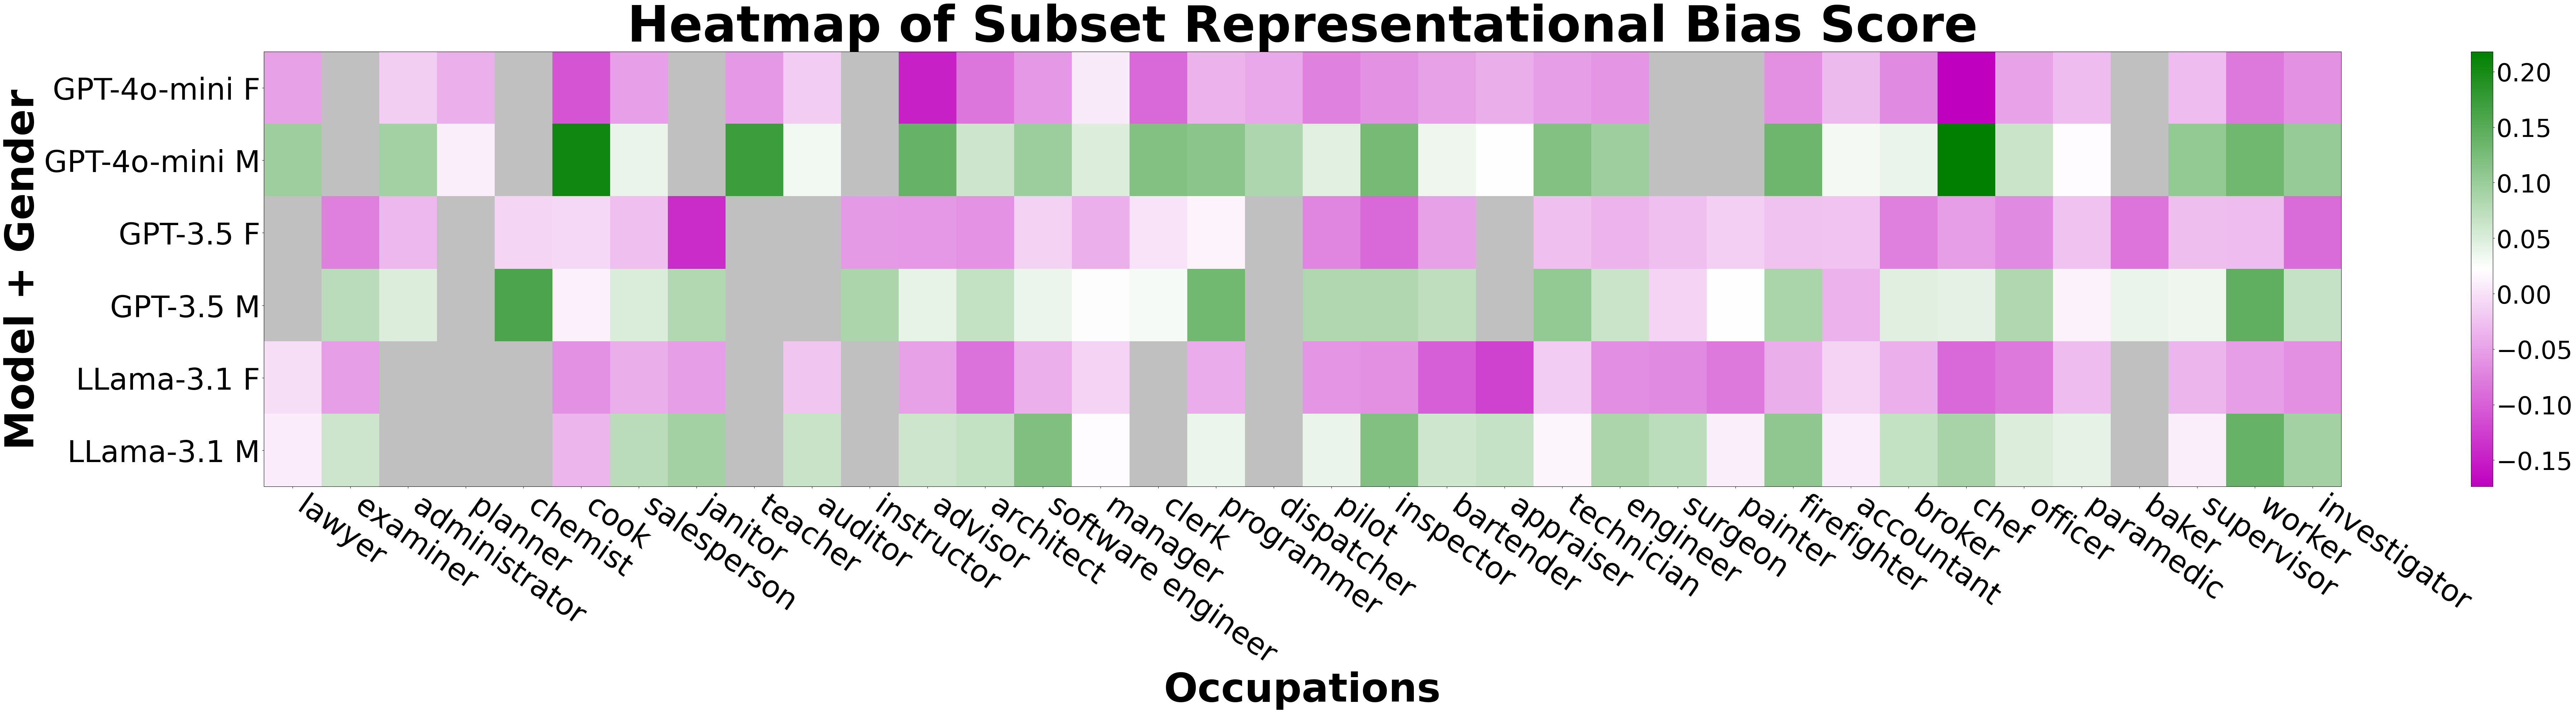

In [31]:
# Creates a heatmap of the subset representation bias scores
max_length = 1
x_labels = list()
for l in all_occupations:
    max_length = max(max_length, len(l))

for occ in all_occupations:
    num_spaces = max_length - len(occ)
    start_spaces = ' ' * num_spaces
    new_occ = occ + start_spaces
    x_labels.append(new_occ)

data = np.array(data)
masked_data = np.ma.array(data, mask=False)
black_and_white_masked_data = np.ma.array(data != 10, mask=False)
y_labels = list()
shortened_model_names = ['GPT-4o-mini', 'GPT-3.5', 'LLama-3.1']
for model in shortened_model_names:
    y_labels.append(f'{model} F')
    y_labels.append(f'{model} M')

for i in range(len(instances_to_mask)):
    var1 = instances_to_mask[i][0]
    var2 = instances_to_mask[i][1]
    masked_data.mask[var1, var2] = True

plt.figure(figsize=(80,20))

# Create the heatmap
plt.imshow(black_and_white_masked_data, cmap=cm.gray, interpolation='nearest', aspect='auto', alpha=0.25)
plt.imshow(masked_data, cmap=LinearSegmentedColormap.from_list('mg',["m", "w", "g"], N=256), interpolation='nearest', aspect='auto')

# Add a color bar
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=50)

# Add axis labels
plt.xticks(
    ticks=np.arange(len(x_labels)), 
    labels=x_labels, 
    rotation=-35,
    fontsize=60,
    ha='left'
)
plt.yticks(
    ticks=np.arange(len(y_labels)),
    labels=y_labels,
    fontsize=60
)

add_values = False
if add_values:
    # Add data value labels inside the heatmap
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            if not masked_data.mask[i, j]:  # Only label non-masked values
                plt.text(j, i, f"{data[i, j]:.2f}", ha='center', va='center', color='black')

# Add titles
plt.title('Heatmap of Subset Representational Bias Score',fontsize=100, weight='bold')
plt.xlabel('Occupations',fontsize=80, weight='bold')
plt.ylabel('Model + Gender',fontsize=80, weight='bold')

# Show the heatmap
plt.tight_layout()
plt.show()

#### Create heatmap showing percent change in Subset Representation Bias Score from GPT-3.5 to GPT-4o-mini

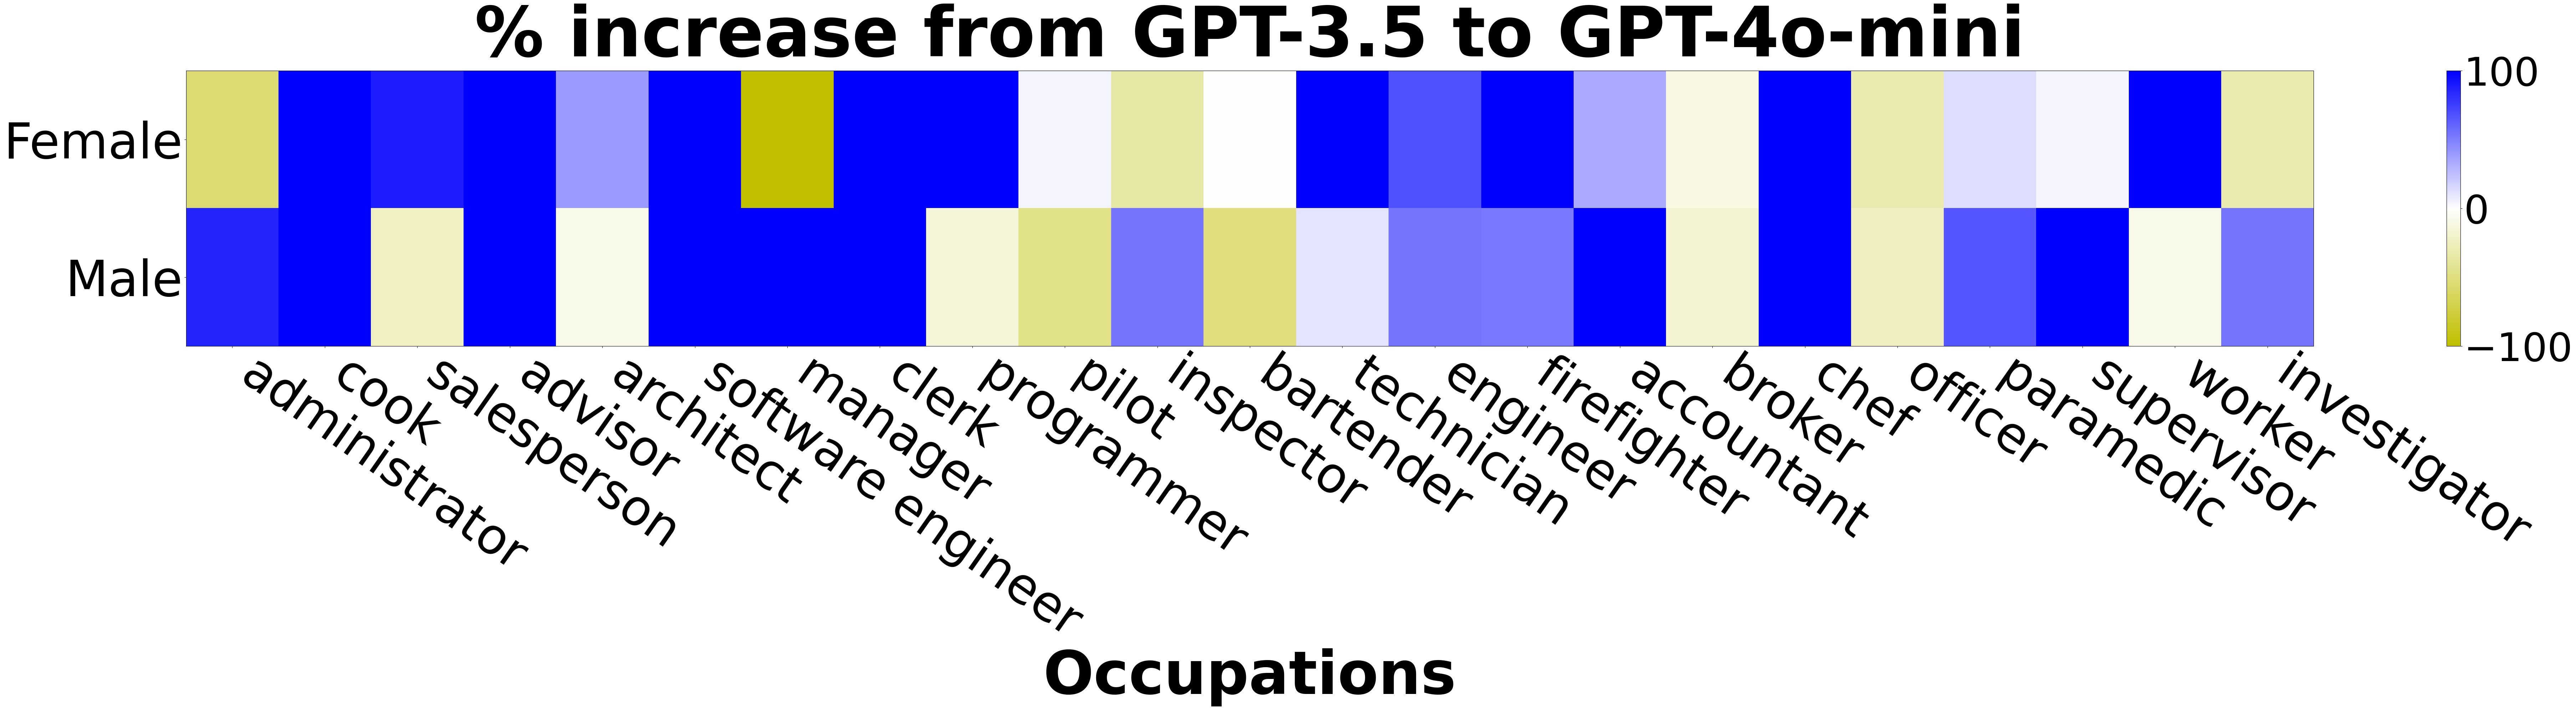

In [32]:
new_data = [[],[]]
new_data[0] = ((data[2] - data[0])/abs(data[2]))*100
new_data[1] = (data[1] - data[3])/abs(data[3])*100

new_data = np.array(new_data)
masked_data = np.ma.array(new_data, mask=False)
y_labels = ['Female', 'Male']
all_occupations = list(set(occupations_gpt4 + occupations_gpt3_5))
x_labels = all_occupations.copy()

to_remove = [0 for i in range(len(new_data[0]))]

for i in range(len(new_data)):
    for j in range(len(new_data[i])):
        if abs(data[i, j]) == 10 or abs(data[i + 2, j]) == 10:
            to_remove[j] += 1
            masked_data.mask[i, j] = True

columns_to_include = list()
labels_to_delete = list()
for i in range(len(to_remove)):
    if to_remove[i] < 2:
        columns_to_include.append(i)
    else:
        labels_to_delete.append(x_labels[i])

for label in labels_to_delete:
    x_labels.remove(label)
selected_columns = masked_data[:, columns_to_include]


plt.figure(figsize=(80,20))

# Create the heatmap
plt.imshow(selected_columns, cmap=LinearSegmentedColormap.from_list('yb',["y", "w", "b"], N=256), interpolation='nearest', aspect='auto', vmin=-100, vmax=100)

# Add a color bar
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=80)

# Add axis labels
plt.xticks(
    ticks=np.arange(len(x_labels)), 
    labels=x_labels, 
    rotation=-35,
    fontsize=100,
    ha='left'
)
plt.yticks(
    ticks=np.arange(len(y_labels)),
    labels=y_labels,
    fontsize=100
)

        
# Add titles
plt.title('% increase from GPT-3.5 to GPT-4o-mini',fontsize=140, weight='bold')
plt.xlabel('Occupations',fontsize=120, weight='bold')

# Show the heatmap
plt.tight_layout()
plt.show()

### Compute statistical significance using a t-test of difference in Subset Representation Bias Score from GPT-3.5 to GPT-4o-mini

In [33]:
str_to_print = ''
all_representation_bias_scored_gpt = dict()

for model in [gpt3_5_name, gpt4_name]:
    all_representation_bias_scored_gpt[model] = {'F': list(), 'M': list()}
for occupation in all_occupations:
    i = 0
    if occupation in representational_bias_scores[gpt3_5_name] and occupation in representational_bias_scores[gpt4_name]:
        for model in [gpt3_5_name, gpt4_name]:
            for g in ['F', 'M']:
                all_representation_bias_scored_gpt[model][g].append(representational_bias_scores[model][occupation][g])

for g in ['F', 'M']:
    t_stat, p_value = ttest_ind(all_representation_bias_scored_gpt[gpt3_5_name][g], all_representation_bias_scored_gpt[gpt4_name][g], equal_var=False)
    str_to_print += f'{g} & {t_stat:.2f} & {p_value}\\\\\n'
    
print("Gender & Welch's t-statistic & p-value\\\\")
print('\\hline')
print(str_to_print)

Gender & Welch's t-statistic & p-value\\
\hline
F & 2.36 & 0.023585407573675513\\
M & -2.69 & 0.010300379371004302\\



### Find the gender distribution of personas and biographies without prompting for gender

In [34]:
# Compute the accuracy of the gender association method
def get_infer_gender_acc(df, occupations, num_gens=100):
    counts_by_gender = dict()
    not_captured = dict()
    
    for occupation in occupations:
        prompts = df[df['occupation'] == occupation]['prompt'].unique()

        counts_by_gender[occupation] = dict()
        not_captured[occupation] = dict()
        for prompt in prompts:
            counts_by_gender[occupation][prompt] = {'M': 0, 'F': 0, 'N': 0}
            not_captured[occupation][prompt] = 0
            prompt_df = df[df['prompt'] == prompt]
            sampled_df = prompt_df.sample(n=num_gens, random_state=42)

            for i in range(len(sampled_df['text'])):
                g = None
                
                if type(sampled_df['text'].iloc[i]) != str:
                    continue

                text = sampled_df['text'].iloc[i].lower()
                g = associate_gender(text)
                if g:
                    counts_by_gender[occupation][prompt][g] += 1
                else:
                    not_captured[occupation][prompt] += 1

    return counts_by_gender, not_captured
        

In [35]:
occupation_stats_filename = 'occupations_stats_from_winogender.tsv'
occupation_data=pd.read_csv(occupation_stats_filename,sep='\t')

occupations = occupation_data['occupation'].unique()
counts_by_gender_gpt4_new, not_captured_gpt4_new = get_infer_gender_acc(df_no_dem_gpt4, occupations)

counts_by_gender_gpt3_new, not_captured_gpt3_new = get_infer_gender_acc(df_no_dem_gpt3, occupations)

counts_by_gender_llama3_new, not_captured_llama3_new = get_infer_gender_acc(df_no_dem_llama3, occupations)


### Calculate the Standard Error of the percentage of generations associated with women

In [36]:
occ_se = dict()

for i, counts_by_gender_model in enumerate([counts_by_gender_gpt3_new, counts_by_gender_gpt4_new, counts_by_gender_llama3_new]):
    occ_se[shortened_model_names[i]] = dict()
    for occ in counts_by_gender_model.keys():
        arr = list()
        for template in counts_by_gender_model[occ].keys():
            arr += [1] * counts_by_gender_model[occ][template]['F'] + [0] * (counts_by_gender_model[occ][template]['M'] + counts_by_gender_model[occ][template]['N'])
        occ_se[shortened_model_names[i]][occ] = stdev(arr)/200



#### Print table of standard errors per occupation and model pair

In [37]:
gpt4_short_name = shortened_model_names[0]
gpt3_5_short_name = shortened_model_names[1]
llama_3_1_short_name = shortened_model_names[2]
standard_error_table_str = "Occupation & "
for model_name in shortened_model_names:
    standard_error_table_str += f"{model_name} SE &"
standard_error_table_str = standard_error_table_str[:-1]
standard_error_table_str += "\\\\\n"
for occ in occupations:
    gpt3_5_occ_se = "N/A"
    gpt4_occ_se = "N/A"
    llama_3_1_occ_se = "N/A"
    if occ in occ_se[gpt3_5_short_name]:
        gpt3_5_occ_se = occ_se[gpt3_5_short_name][occ]
    if occ in occ_se[gpt4_short_name]:
        gpt4_occ_se = occ_se[gpt4_short_name][occ]
    if occ in occ_se[llama_3_1_short_name]:
        llama_3_1_occ_se = occ_se[llama_3_1_short_name][occ]
    standard_error_table_str += f"{occ} & {gpt4_occ_se} & {gpt3_5_occ_se} & {llama_3_1_occ_se}\\\\\n"

print(standard_error_table_str)


Occupation & GPT-4o-mini SE &GPT-3.5 SE &LLama-3.1 SE \\
technician & 0.001971111952258775 & 0.0013619246343602937 & 0.0015037641213512564\\
accountant & 0.0022439757386557243 & 0.001742962092821394 & 0.001363001730398828\\
supervisor & 0.0021572660724440166 & 0.0020915718840387766 & 0.0015967558187937373\\
engineer & 0.0023744118176713467 & 0.0024504950741379553 & 0.0024857510934416034\\
worker & 0.0022998174118546467 & 0.0022215433382394 & 0.002024173236942328\\
educator & 0.0006265810801888759 & 0.0006092874163963133 & 0.0\\
clerk & 0.0021086369598665943 & 0.002080190258875654 & 0.0009234438756318972\\
counselor & 0.0005954607326011406 & 0.0006123253355583795 & 0.0\\
inspector & 0.0022503238108961144 & 0.002350823094117581 & 0.001946359828735317\\
mechanic & 0.0 & 0.00035355339059327376 & 0.0\\
manager & 0.0022217921840523088 & 0.0017022920972453775 & 0.0020208338955757478\\
therapist & 0.0 & 0.0 & 0.0\\
administrator & 0.001991931236462284 & 0.0021165401420980274 & 0.00035805743701

### Create graphs showing the percent of female and non-binary representation for male-dominated and female-dominated occupations

In [ ]:
def create_below_and_above_50_graphs(g, _templates=None):
    below50 = dict()
    above50 = dict()
    num_partitions = 10
    x_labels = list()
    if _templates != None and len(_templates) == 1:
        prompt_name = f"for \n'{_templates[0]}' prompt"
    else:
        prompt_name = ''

    for i in range(num_partitions):
        x_labels.append(f'{i*10} - {(i+1)*10} %')

    models = ['LBS', 'GPT-3.5', 'Llama-3.1', 'GPT-4']
    for model in models:
        below50[model] = [0 for i in range(10)]
        above50[model] = [0 for i in range(10)]
    for i in range(len(occupation_data)):
        if g == 'M':
            occ_perc = 100 - occupation_data.iloc[i]['bls_pct_female']
        else:
            occ_perc = occupation_data.iloc[i]['bls_pct_female']
        occupation = occupation_data.iloc[i]['occupation']
        gpt3_5_avg_new = 0
        gpt3_5_counts_new = 0
        if _templates == None:
            templates = counts_by_gender_gpt3_new[occupation]
        else:
            templates = list()
            for template in _templates:
                if type(template) is not str:
                    continue
                templates.append(template%occupation)
        for template in templates:
            gpt3_5_avg_new += counts_by_gender_gpt3_new[occupation][template][g]
            gpt3_5_counts_new += 1
        gpt3_5_avg_new = gpt3_5_avg_new / gpt3_5_counts_new
        llama3_avg_new = 0
        llama3_counts_new = 0
        for template in templates:
            llama3_avg_new += counts_by_gender_llama3_new[occupation][template][g]
            llama3_counts_new += 1
        llama3_avg_new = llama3_avg_new / llama3_counts_new
        gpt4_avg_new = 0
        gpt4_counts_new = 0
        for template in templates:
            gpt4_avg_new += counts_by_gender_gpt4_new[occupation][template][g]
            gpt4_counts_new += 1
        gpt4_avg_new = gpt4_avg_new / gpt4_counts_new
        if occ_perc < 50:
            below50['LBS'][int(occ_perc//num_partitions)] += 1
            below50['GPT-3.5'][min(9, int(gpt3_5_avg_new//num_partitions))] += 1
            below50['Llama-3.1'][min(9, int(llama3_avg_new//num_partitions))] += 1
            below50['GPT-4'][min(9, int(gpt4_avg_new//num_partitions))] += 1
        else:
            above50['LBS'][min(9, int(occ_perc//num_partitions))] += 1
            above50['GPT-3.5'][min(9, int(gpt3_5_avg_new//num_partitions))] += 1
            above50['Llama-3.1'][min(9, int(llama3_avg_new//num_partitions))] += 1
            above50['GPT-4'][min(9, int(gpt4_avg_new//num_partitions))] += 1


    BAR_WIDTH = 0.2
    FONTSIZE_TITLE = 50
    FONTSIZE_LABEL = 40
    FONTSIZE_TICKS = 35
    offsets = [-1.5 * BAR_WIDTH, -0.5 * BAR_WIDTH, 0.5 * BAR_WIDTH, 1.5 * BAR_WIDTH]

    # Style settings
    plt.style.use('seaborn-muted')
    color_palette = ['r', 'c', 'b', 'm']

    # Create the first graph
    plt.figure(figsize=(50, 8))  # Adjust the figure size
    plt.subplot(1, 2, 1)
    plt.bar(np.arange(10) + offsets[0], below50['LBS'], width=BAR_WIDTH, label='Bureau of Labor and Statistics', color=color_palette[0])
    plt.bar(np.arange(10) + offsets[1], below50['GPT-3.5'], width=BAR_WIDTH, label='GPT-3.5', color=color_palette[1])
    plt.bar(np.arange(10) + offsets[2], below50['GPT-4'], width=BAR_WIDTH, label='GPT-4o-mini', color=color_palette[2])
    plt.bar(np.arange(10) + offsets[3], below50['Llama-3.1'], width=BAR_WIDTH, label='Llama-3.1', color=color_palette[3])
    plt.xticks(np.arange(10), x_labels, rotation=25, fontsize=FONTSIZE_TICKS)
    plt.yticks(fontsize=FONTSIZE_TICKS)
    plt.title("\n".join(wrap(f"% Women in Male-Dominated Occupations {prompt_name}", width=45)), fontsize=FONTSIZE_TITLE, weight='bold')
    plt.xlabel("% of Women", fontsize=FONTSIZE_LABEL, weight='bold')
    plt.ylabel("# of Occupations", fontsize=FONTSIZE_LABEL, weight='bold')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Create the second graph
    plt.subplot(1, 2, 2)
    plt.bar(np.arange(10) + offsets[0], above50['LBS'], width=BAR_WIDTH, color=color_palette[0])
    plt.bar(np.arange(10) + offsets[1], above50['GPT-3.5'], width=BAR_WIDTH, color=color_palette[1])
    plt.bar(np.arange(10) + offsets[2], above50['GPT-4'], width=BAR_WIDTH, color=color_palette[2])
    plt.bar(np.arange(10) + offsets[3], above50['Llama-3.1'], width=BAR_WIDTH, color=color_palette[3])
    plt.xticks(np.arange(10), x_labels, rotation=25, fontsize=FONTSIZE_TICKS)
    plt.yticks(fontsize=FONTSIZE_TICKS)
    plt.title("\n".join(wrap(f"% of Women in Female-Dominated Occupations {prompt_name}", width=45)), fontsize=FONTSIZE_TITLE, weight='bold')
    plt.xlabel("% of Women", fontsize=FONTSIZE_LABEL, weight='bold')
    plt.ylabel("# of Occupations", fontsize=FONTSIZE_LABEL, weight='bold')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.figlegend(loc='lower center', ncol=3, fontsize=FONTSIZE_TICKS, frameon=False, bbox_to_anchor=(0.5,-0.4))

GPT-4o-mini non-binary % zero 35
GPT-4o-mini non-binary % non-zero 28
GPT-4o-mini non-binary % greater than US 12


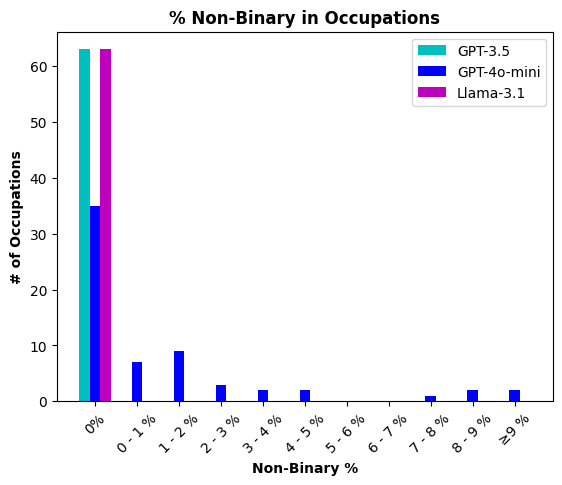

In [39]:
def create_below_and_above_50_graphs_non_binary(_templates=None):
    g='N'
    total = dict()
    num_partitions = 10
    x_labels = ['0%']

    for i in range(num_partitions):
        x_labels.append(f'{i} - {(i+1)} %')
    x_labels[-1] = f'≥{num_partitions-1} %'

    models = ['GPT-3.5', 'Llama-3.1', 'GPT-4']
    bar_width = .25
    offsets = [-bar_width, 0, bar_width]
    for model in models:
        total[model] = [0 for i in range(11)]

    zero_gpt4 = 0
    non_zero_gpt4 = 0
    greater_than_us_gpt4 = 0
    for i in range(len(occupation_data)):
        occupation = occupation_data.iloc[i]['occupation']
        gpt3_5_avg_new = 0
        gpt3_5_counts_new = 0
        if _templates == None:
            templates = counts_by_gender_gpt3_new[occupation]
        else:
            templates = list()
            for template in _templates:
                if type(template) is not str:
                    continue
                templates.append(template%occupation)
        for template in templates:
            gpt3_5_avg_new += counts_by_gender_gpt3_new[occupation][template][g]
            gpt3_5_counts_new += 1
        gpt3_5_avg_new = gpt3_5_avg_new / gpt3_5_counts_new
        llama3_avg_new = 0
        llama3_counts_new = 0
        for template in templates:
            llama3_avg_new += counts_by_gender_llama3_new[occupation][template][g]
            llama3_counts_new += 1
        llama3_avg_new = llama3_avg_new / llama3_counts_new
        gpt4_avg_new = 0
        gpt4_counts_new = 0
        for template in templates:
            gpt4_avg_new += counts_by_gender_gpt4_new[occupation][template][g]
            gpt4_counts_new += 1
        gpt4_avg_new = gpt4_avg_new / gpt4_counts_new

        if gpt3_5_avg_new == 0:
            total['GPT-3.5'][0] += 1
        else:
            total['GPT-3.5'][min(9, int(gpt3_5_avg_new))+1] += 1
        if llama3_avg_new == 0:
            total['Llama-3.1'][0] += 1
        else:
            total['Llama-3.1'][min(9, int(llama3_avg_new))+1] += 1
        if gpt4_avg_new == 0:
            total['GPT-4'][0] += 1
            zero_gpt4 += 1
        else:
            total['GPT-4'][min(9, int(gpt4_avg_new))+1] += 1
            non_zero_gpt4 += 1
            if gpt4_avg_new >= 1.6:
                greater_than_us_gpt4 += 1
        

    # create <50% graph
    plt.bar(np.arange(0,11)+offsets[0], total['GPT-3.5'], width=bar_width, label='GPT-3.5', color='c')
    plt.bar(np.arange(0,11)+offsets[1], total['GPT-4'], width=bar_width, label='GPT-4o-mini', color='b')
    plt.bar(np.arange(0,11)+offsets[2], total['Llama-3.1'], width=bar_width, label='Llama-3.1', color='m')
    plt.xticks(np.arange(0,11), x_labels, rotation=45)
    plt.title(f'% Non-Binary in Occupations', weight='bold')
    plt.xlabel('Non-Binary %', weight='bold')
    plt.ylabel('# of Occupations', weight='bold')

    plt.legend()

    print('GPT-4o-mini non-binary % zero', zero_gpt4)
    print('GPT-4o-mini non-binary % non-zero', non_zero_gpt4)
    print('GPT-4o-mini non-binary % greater than US', greater_than_us_gpt4)
    plt.show()

create_below_and_above_50_graphs_non_binary()
        

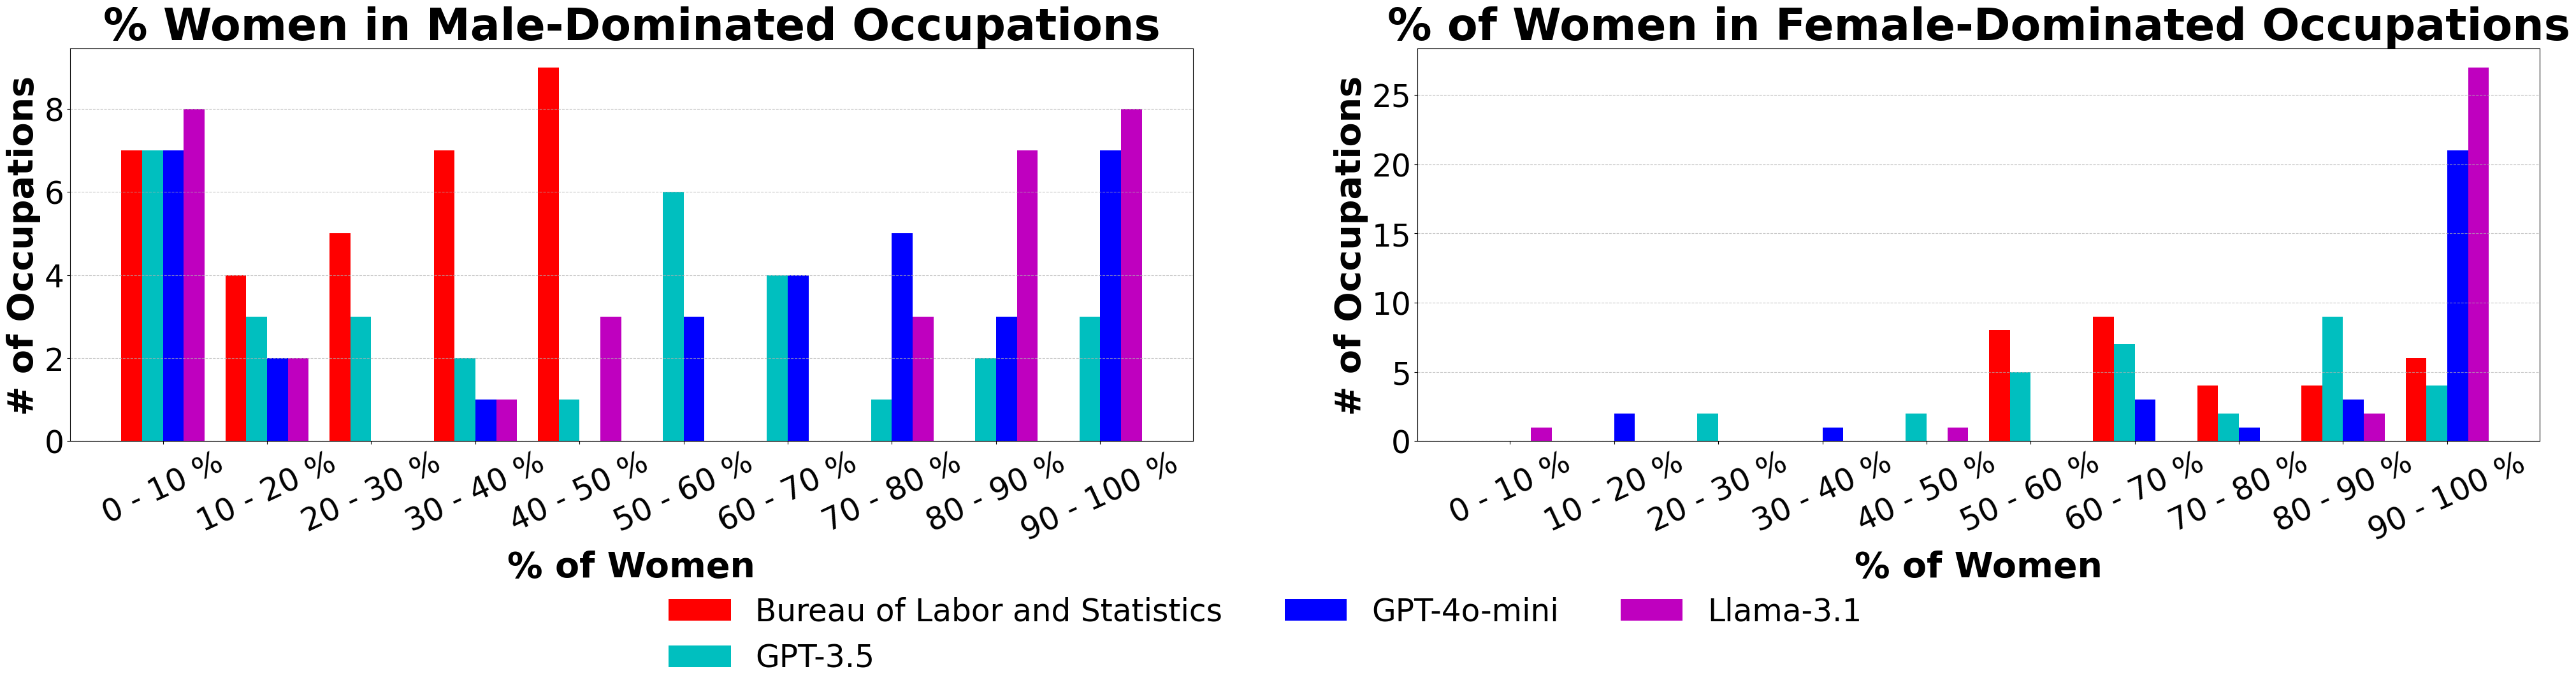

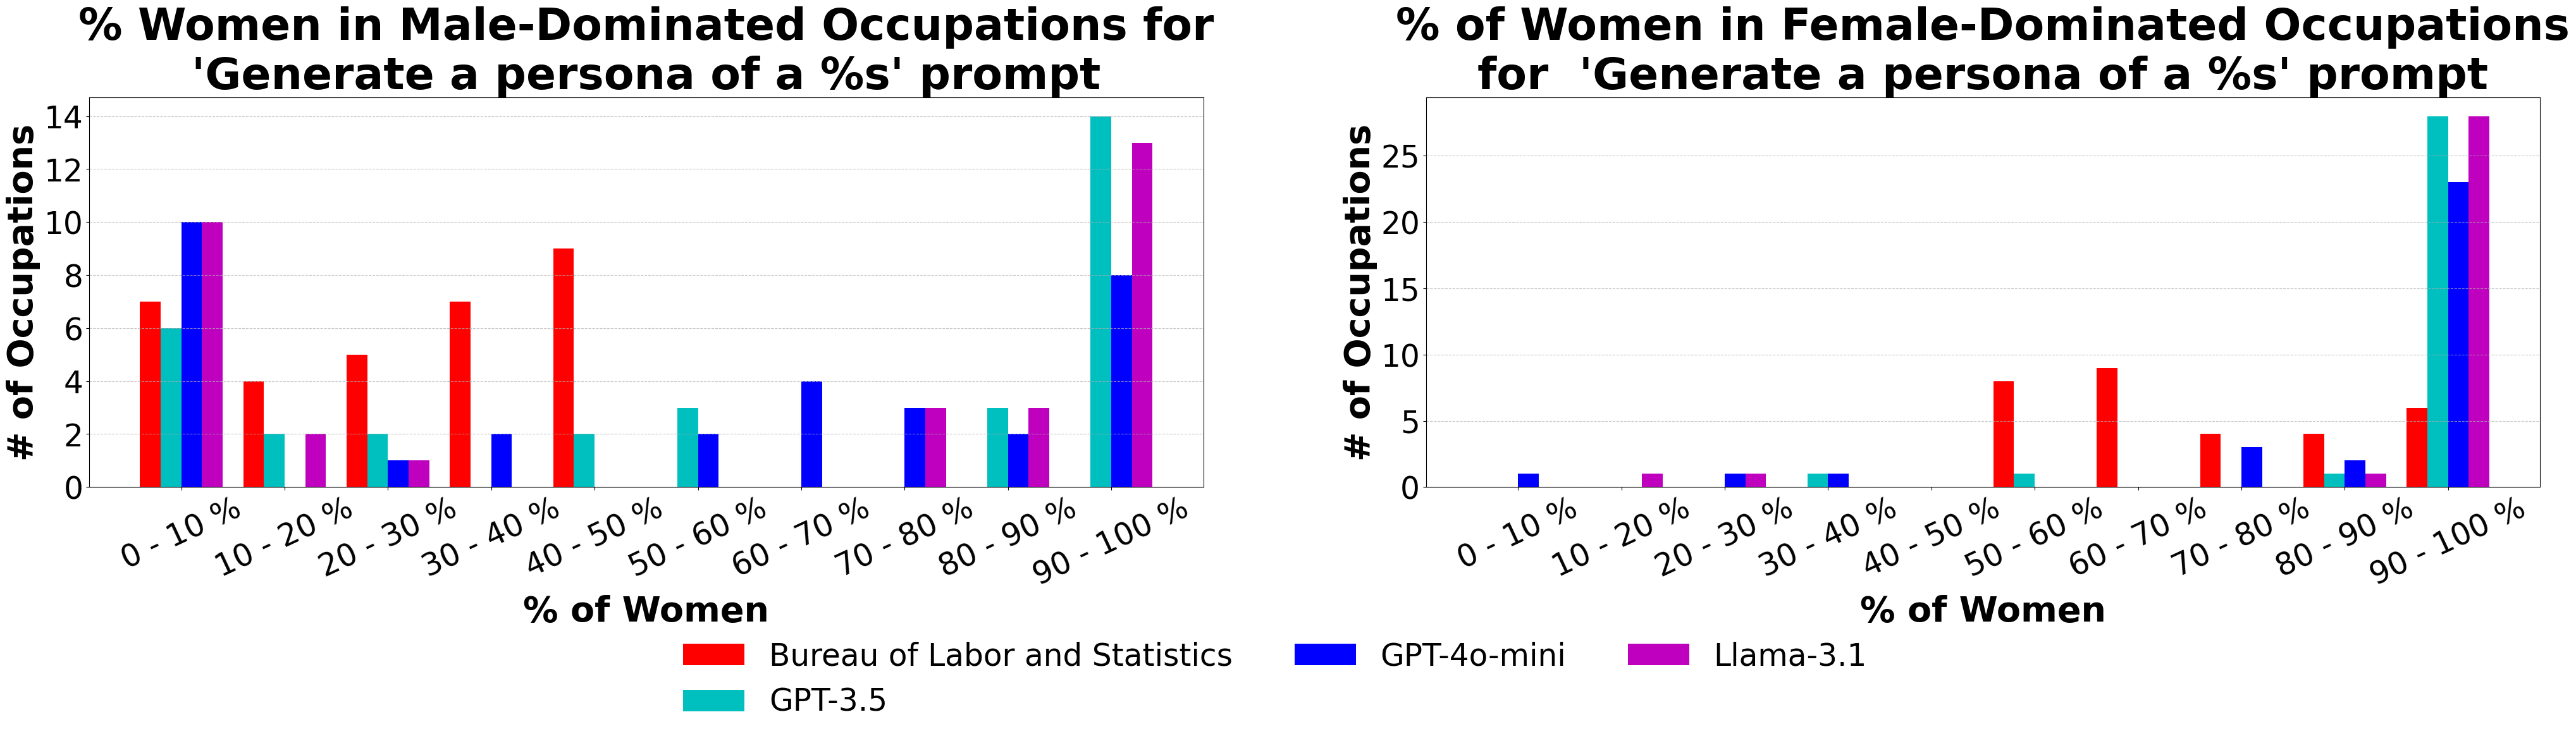

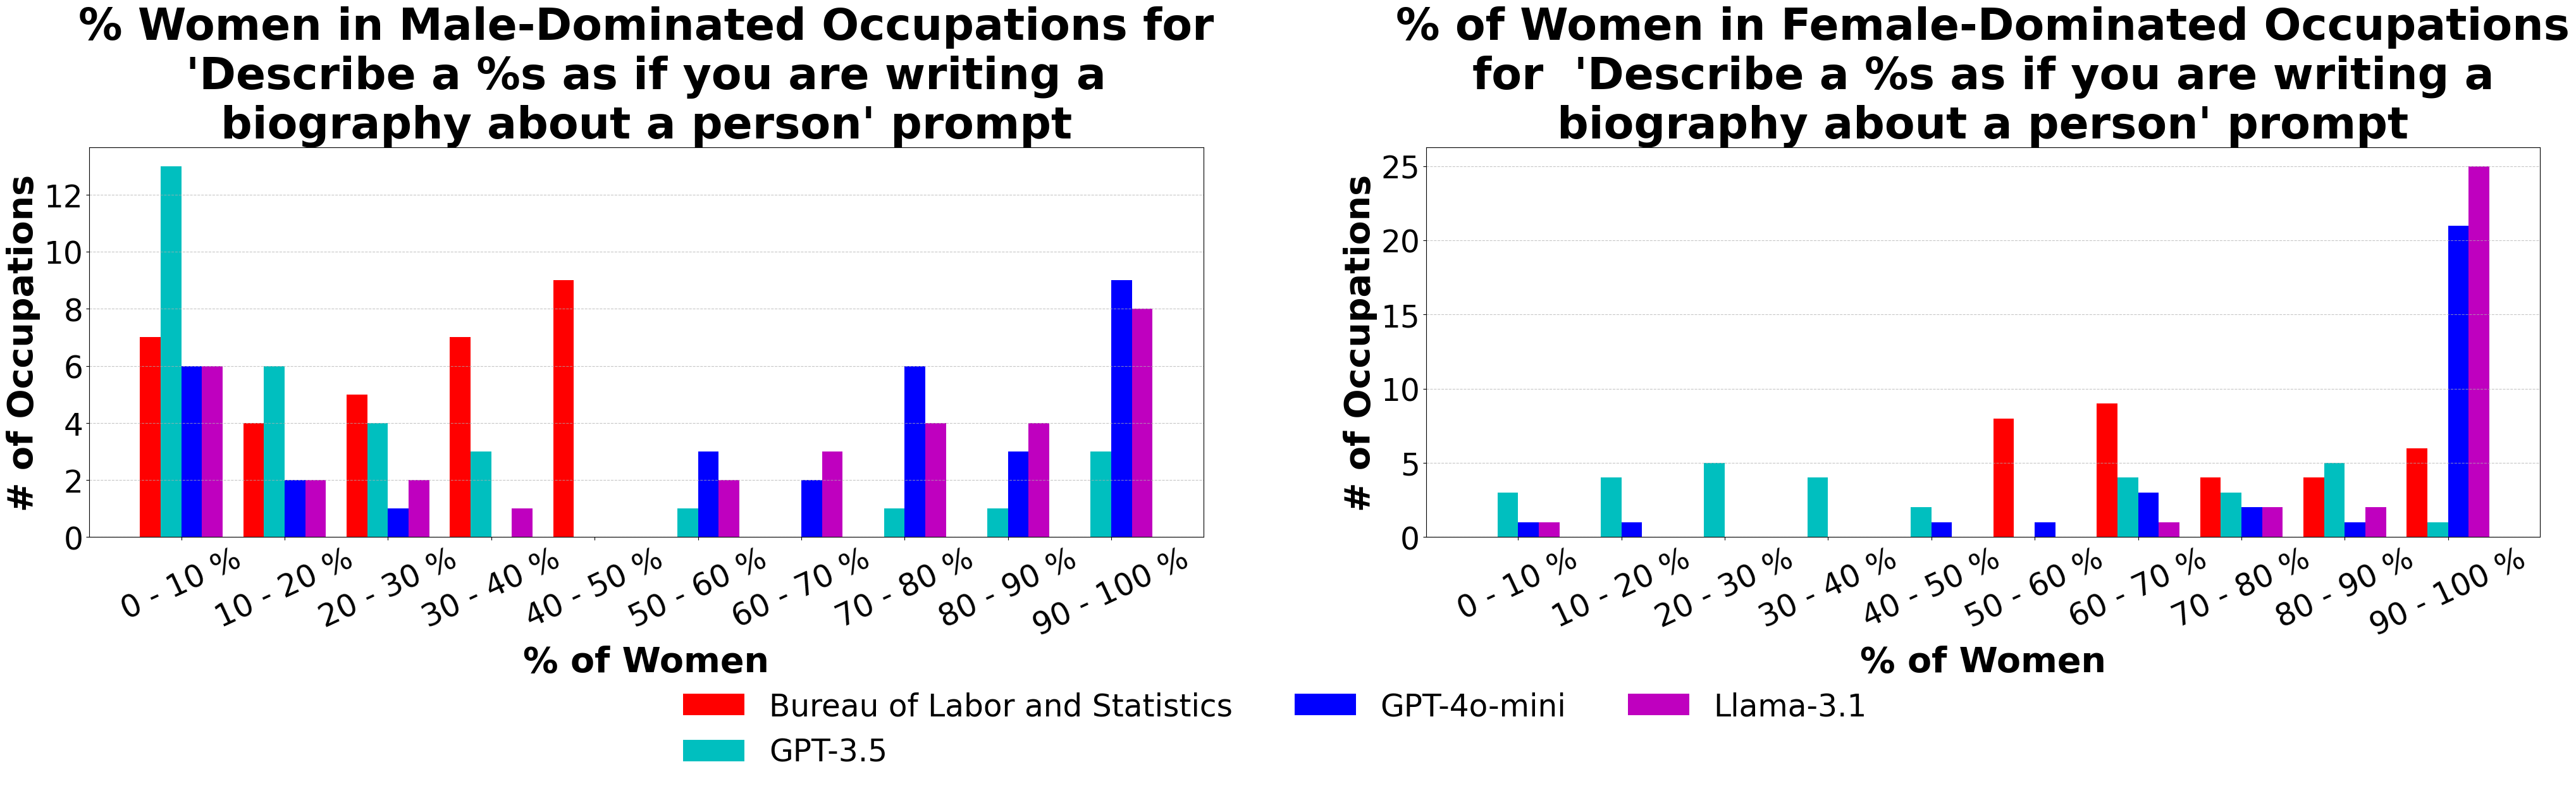

In [40]:
prompt_templates = ['Generate a persona of a %s', 'Describe a %s as if you are writing a biography about a person']
create_below_and_above_50_graphs('F', prompt_templates)

for prompt_template in prompt_templates:
    create_below_and_above_50_graphs('F',[prompt_template])



In [41]:
# stores calibrated marked words for generated text in a csv file (calibrated_marked_words_from_generated_biographies_and_personas.csv)
def save_calibrated_marked_words(dv3_mw_by_occ_inferred_genders, dv3_mw_by_occ_genders, models):
    words_to_save = {'occupation': [], 'model': [], 'gender': [], 'calibrated_marked_words': []}
    for i in range(len(dv3_mw_by_occ_inferred_genders)):
        for occ in dv3_mw_by_occ_inferred_genders[i].keys():
            for g in ['M', 'F', 'N']:
                if g in dv3_mw_by_occ_inferred_genders[i][occ]:
                    words_to_save['occupation'].append(occ)
                    words_to_save['model'].append(models[i])
                    words_to_save['gender'].append(f'associated {g}')
                    words_to_save['calibrated_marked_words'].append(dv3_mw_by_occ_genders[i][occ][g])
    for i in range(len(dv3_mw_by_occ_genders)):
        for occ in dv3_mw_by_occ_genders[i].keys():
            for g in ['M', 'F', 'N']:
                if g in dv3_mw_by_occ_genders[i][occ]:
                    words_to_save['occupation'].append(occ)
                    words_to_save['model'].append(models[i])
                    words_to_save['gender'].append(f'specified {g}')
                    words_to_save['calibrated_marked_words'].append(dv3_mw_by_occ_genders[i][occ][g])
    df = pd.DataFrame(words_to_save)
    df.to_csv('calibrated_marked_words_from_generated_biographies_and_personas.csv')

save_calibrated_marked_words( [dv3_mw_by_occ_inferred_gender_gpt4, dv3_mw_by_occ_inferred_gender_gpt3_5, dv3_mw_by_occ_inferred_gender_llama3], [dv3_mw_by_occ_gender_gpt4,dv3_mw_by_occ_gender_gpt3_5, dv3_mw_by_occ_gender_llama3],['gpt-4o-mini', 'gpt-3.5', 'llama-3.1'])

### Create tables exhibiting calibrated marked words

In [42]:
def print_marked_words_table(occupations_to_investigate, dv3_mw_by_occ_inferred_genders, dv3_mw_by_occ_genders, models):
    print('Occupation & Model & Gender & Marked Words\\\\')
    print('\\hline\\\\')
    for occ_to_investigate in occupations_to_investigate:
        str_to_print = f"{occ_to_investigate} "
        for i in range(len(dv3_mw_by_occ_inferred_genders)):
            if occ_to_investigate not in dv3_mw_by_occ_inferred_genders[i]:
                continue
            str_to_print += f"& {models[i]} & F & "
            associated_words_seen = set()
            for word in dv3_mw_by_occ_inferred_genders[i][occ_to_investigate]['F']:
                if word in dv3_mw_by_occ_genders[i][occ_to_investigate]['F']:
                    str_to_print += '\\textbf{%s}, '%word
                    associated_words_seen.add(word)
                else:
                    if word in dv3_mw_by_occ_genders[i][occ_to_investigate]['M']:
                        str_to_print += '\\underline{%s}, '%word
                    else:
                        str_to_print += f'{word}, '
            for word in dv3_mw_by_occ_genders[i][occ_to_investigate]['F']:
                if word not in associated_words_seen:
                    str_to_print += '\\gray{%s}, '%word
            print(str_to_print[:-2], '\\\\')
            str_to_print = f"& & M & "
            associated_words_seen = set()
            for word in dv3_mw_by_occ_inferred_genders[i][occ_to_investigate]['M']:
                if word in dv3_mw_by_occ_genders[i][occ_to_investigate]['M']:
                    str_to_print += '\\textbf{%s}, '%word
                    associated_words_seen.add(word)
                else:
                    if word in dv3_mw_by_occ_genders[i][occ_to_investigate]['F']:
                        str_to_print += '\\underline{%s}, '%word
                    else:
                        str_to_print += f'{word}, '
            for word in dv3_mw_by_occ_genders[i][occ_to_investigate]['M']:
                if word not in associated_words_seen:
                    str_to_print += '\\gray{%s}, '%word
            str_to_print = str_to_print[:-2] + '\\\\'
        print(str_to_print)


In [43]:
occupations_gpt4o_mini = dv3_mw_by_occ_gender_gpt4.keys()
occupations_gpt3_5= dv3_mw_by_occ_gender_gpt3_5.keys()
occupations_llama3 = dv3_mw_by_occ_gender_llama3.keys()
all_occupations = set(list(occupations_gpt4o_mini) + list(occupations_gpt3_5) + list(occupations_llama3))
print_marked_words_table(all_occupations, [dv3_mw_by_occ_inferred_gender_gpt4, dv3_mw_by_occ_inferred_gender_gpt3_5, dv3_mw_by_occ_inferred_gender_llama3], [dv3_mw_by_occ_gender_gpt4,dv3_mw_by_occ_gender_gpt3_5, dv3_mw_by_occ_gender_llama3],['gpt-4o-mini', 'gpt-3.5', 'llama-3.1'])

Occupation & Model & Gender & Marked Words\\
\hline\\
lawyer & gpt-4o-mini & F & \textbf{her}, \textbf{she}, \textbf{herself}, \textbf{alexandra}, \textbf{practicing}, \textbf{daughter}, \textbf{women}, undergraduate, \textbf{yoga}, \textbf{aspiring}, \textbf{workshops}, \textbf{oregon}, \textbf{francisco}, \textbf{fierce}, educators, \textbf{activism}, using, bachelors, housing, sophie, \textbf{san}, \textbf{nonprofit}, individuals, testament, \textbf{california}, \textbf{discrimination}, dc, \gray{environmental}, \gray{womens}, \gray{female}, \gray{field}, \gray{diversity}, \gray{equality}, \gray{rights}, \gray{empowering}, \gray{profession}, \gray{gender}, \gray{resilience}, \gray{seattle}, \gray{rescue}, \gray{workplace}, \gray{advocacy}, \gray{stanford}, \gray{pursuing}, \gray{bella}, \gray{award}, \gray{barriers}, \gray{organization}, \gray{l}, \gray{actively}, \gray{leadership}, \gray{underrepresented}, \gray{conferences}, \gray{sustainable}, \gray{pacific}, \gray{northwest}, \g

### Run k means and remove words that should not be clustered (i.e. names and ≤3 letter words) 

In [44]:
def get_words_across_gender(dv3_mw_by_occ):
    words_across_occ_by_gender = {'M': [], 'F': [], 'N': []}
    for occ in dv3_mw_by_occ.keys():
        for g in dv3_mw_by_occ[occ].keys():
            words_across_occ_by_gender[g] += dv3_mw_by_occ[occ][g]
    return words_across_occ_by_gender
gpt3_5_words_across_occ_by_gender = get_words_across_gender(dv3_mw_by_occ_inferred_gender_gpt3_5)
gpt4_words_across_occ_by_gender = get_words_across_gender(dv3_mw_by_occ_inferred_gender_gpt4)
llama3_words_across_occ_by_gender = get_words_across_gender(dv3_mw_by_occ_inferred_gender_llama3)

In [45]:
def print_dist_by_cluster(cluster_label_to_word, dv3_mw_by_occ=dv3_mw_by_occ_inferred_gender_gpt3_5, max_radius=None):
    # prints the max distance in a given cluster
    cluster_label_nums = dict()
    for i in cluster_label_to_word.keys():
        cluster_label_nums[i] = {'F':0, 'M': 0}
    for dv3_mw_by_occ in [dv3_mw_by_occ_inferred_gender_gpt3_5, dv3_mw_by_occ_inferred_gender_gpt4, dv3_mw_by_occ_inferred_gender_llama3]:
        for occ in dv3_mw_by_occ.keys():
            for g in dv3_mw_by_occ[occ].keys():
                for i in cluster_label_to_word.keys():
                    for word in cluster_label_to_word[i]:
                        if word in dv3_mw_by_occ[occ][g]:
                            cluster_label_nums[i][g] += 1
                            break

    print(cluster_label_nums)
    for i in cluster_label_nums.keys():
        if max_radius:
            print(i, cluster_label_nums[i], max_radius[i])
        else:
            print(i, cluster_label_nums[i])
        print(set(cluster_label_to_word[i]))


In [46]:
words_across_occ = list()
for words_across_occ_by_gender in [gpt3_5_words_across_occ_by_gender, gpt4_words_across_occ_by_gender, llama3_words_across_occ_by_gender]:
    words_across_occ += list(words_across_occ_by_gender['F']) + list(words_across_occ_by_gender['M'])
words_across_occ = list(set(words_across_occ))
print(len(words_across_occ),words_across_occ)

2902 ['retire', 'hale', 'principles', 'lodie', 'codecraft', 'learn', 'closer', 'croissant', 'meetings', 'instructor', 'sports', 'martha', 'anaya', 'modeling', 'sicily', 'keen', 'counselor', 'xyz', 'eager', 'herself', 'flair', 'who', 'advocates', 'accountants', 'experiments', 'nate', 'strategist', 'inclusive', 'teamwork', 'alexandras', 'opportunity', 'axels', 'woman', 'naval', 'intricacies', 'pendant', 'scrutiny', 'dedication', 'experimenting', 'simplicity', 'ems', 'enabling', 'empathy', 'infernos', 'pioneering', 'tattoos', 'associate', 'office', 'impeccably', 'salad', 'avid', 'nature', 'whose', 'rugged', 'sully', 'promoted', 'certification', 'art', 'claudia', 'teachers', 'oregon', 'birthplace', 'skilled', 'fpa', 'financial', 'paintings', 'fea', 'wanted', 'complexion', 'guggenheim', 'enhancing', 'hosts', 'bul', 'candid', 'city', 'investigation', 'academic', 'supervisor', 'puttogether', 'volunteered', 'entrepreneurial', 'destination', 'showed', 'twists', 'confidence', 'augusts', 'collar'

In [49]:
# Download if not already done
nltk.download('names')

name_list = set(name.lower() for name in names.words())

[nltk_data] Downloading package names to /Users/Jen/nltk_data...
[nltk_data]   Package names is already up-to-date!


In [50]:
words_to_remove = list()
for word in words_across_occ:
    if len(word) == 1:
        words_to_remove.append(word)
print(words_to_remove)

['e', 'm', 't', 'w', 'p', 'd', 'y', 'h', 'r', 'l', 'f']


In [ ]:
for word in words_across_occ:
    word1 = word[:-1]
    if word in name_list:
        words_to_remove.append(word)
    elif word1 in name_list:
        words_to_remove.append(word)
    
print(len(words_to_remove),words_to_remove)

345 ['e', 'm', 't', 'w', 'p', 'd', 'y', 'h', 'r', 'l', 'f', 'hale', 'martha', 'keen', 'nate', 'alexandras', 'axels', 'ems', 'avid', 'sully', 'art', 'claudia', 'candid', 'augusts', 'trips', 'simona', 'reginalds', 'herbs', 'loves', 'vie', 'edward', 'rival', 'path', 'deep', 'anya', 'everett', 'norma', 'bella', 'tame', 'isabelle', 'luke', 'terry', 'pierres', 'mick', 'jacques', 'iraq', 'axel', 'wine', 'florence', 'harmon', 'avas', 'isabel', 'sophie', 'pierre', 'felix', 'clair', 'liam', 'helen', 'august', 'roses', 'rory', 'elise', 'carolina', 'reggie', 'althea', 'marino', 'anthony', 'joan', 'ally', 'millie', 'anabelle', 'way', 'eric', 'miranda', 'aurlie', 'stern', 'ella', 'haven', 'emilie', 'urban', 'sky', 'leaf', 'carries', 'celeste', 'aurlien', 'alexei', 'piper', 'prescott', 'berkeley', 'antoni', 'fan', 'evies', 'em', 'charity', 'pennys', 'jules', 'honor', 'van', 'richmond', 'marlowe', 'belle', 'dan', 'temples', 'harold', 'westbrook', 'emory', 'chip', 'rusty', 'alexandra', 'adrians', 'fran

In [52]:
cleaned_words_across_occ = words_across_occ.copy()
for word in words_to_remove:
    if word in cleaned_words_across_occ:
        cleaned_words_across_occ.remove(word)
print(len(cleaned_words_across_occ),cleaned_words_across_occ)

2557 ['retire', 'principles', 'lodie', 'codecraft', 'learn', 'closer', 'croissant', 'meetings', 'instructor', 'sports', 'anaya', 'modeling', 'sicily', 'counselor', 'xyz', 'eager', 'herself', 'flair', 'who', 'advocates', 'accountants', 'experiments', 'strategist', 'inclusive', 'teamwork', 'opportunity', 'woman', 'naval', 'intricacies', 'pendant', 'scrutiny', 'dedication', 'experimenting', 'simplicity', 'enabling', 'empathy', 'infernos', 'pioneering', 'tattoos', 'associate', 'office', 'impeccably', 'salad', 'nature', 'whose', 'rugged', 'promoted', 'certification', 'teachers', 'oregon', 'birthplace', 'skilled', 'fpa', 'financial', 'paintings', 'fea', 'wanted', 'complexion', 'guggenheim', 'enhancing', 'hosts', 'bul', 'city', 'investigation', 'academic', 'supervisor', 'puttogether', 'volunteered', 'entrepreneurial', 'destination', 'showed', 'twists', 'confidence', 'collar', 'corn', 'addition', 'corps', 'citys', 'womenintech', 'forefront', 'exhibitions', 'experiencing', 'took', 'thrive', 'ea

In [53]:
words_2letter = list()
for word in cleaned_words_across_occ:
    if len(word) == 2:
        words_2letter.append(word)
for word in ['dr', 'md']:
    if word in words_2letter:
        words_2letter.remove(word)
print(len(words_2letter),words_2letter)
for word in words_2letter:
    cleaned_words_across_occ.remove(word)


23 ['kg', 'da', 'he', 'om', 'cj', 'gr', 'mr', 'le', 'ex', 'ob', 'st', 'dc', 'ms', 'ny', 'co', 'pe', 'wd', 'cb', 'pm', 'eg', 'ej', 'of', 'th']


In [54]:
# set of words manually excepted that should not be clustered
# this set is described within the appendix of the paper
words_to_remove = [
    "anaya", "luca", "luc", "trunc", "deluca", "rowan", "michaelson", "cla", "lapierre", "delacroix",
    "langford", "lafleur", "lafleurs", "hartman", "hartfield", "soph", "cfd", "baff", "caf", "cae",
    "ria", "thats", "those", "gio", "gogh", "goghs", "glo", "lodie", "pers", "eliana", "ember", "elara",
    "numer", "dumont", "dupont", "duponts", "beaumont", "mercer", "mercers", "myers", "alexandre",
    "alexandres", "alexandria", "auri", "alistair", "albright", "alessi", "aristide", "amlie",
    "aurelio", "ark", "aurliens", "bastu", "babel", "braz", "bastien", "dab", "zaha", "iata", "bul",
    "hargrove", "hargrave", "holloway", "october", "standingsmoctober", "thcentury", "xyz", "ven",
    "cvn", "vittorio", "voss", "jds", "ajs", "jaxs", "jax", "johansson", "javi", "juliens", "uss",
    "tennyson", "greyson", "kensington", "ellison", "wynter", "ryder", "rybeck", "poque", "polit",
    "prob", "pon", "pul", "aldridge", "eldridge", "bru", "livs", "vitale", "vidalect", "influenceatom",
    "artservals", "anim", "blackwood", "maplewood", "oakdale", "secre", "lexis", "sel", "atticus",
    "asq", "res", "gaud", "fitzpatrick", "fpa", "aicpa", "fea", "fdny", "has", "whose", "non",
    "como", "video", "ainsworth", "thornes", "amaro", "absor", "hughes", "hawkins", "hawkeye",
    "jeanpierre", "caruso", "cartwright", "mishra", "opp", "onc", "nik", "name", "cott", "finch", "make", "marceau", 
    "would", "accom", "rmi", "couldnt", "organisus", "steele", "persona"
]

for word in words_to_remove:
    if word in cleaned_words_across_occ:
        cleaned_words_across_occ.remove(word)


In [55]:
len(cleaned_words_across_occ)

2424

In [68]:
model = SentenceTransformer("BAAI/bge-m3")

In [ ]:
def run_k_means(dv3, num_clusters=50, print_info=False, print_dist=False, print_cluster_info=False):
    documents = cleaned_words_across_occ

    word_vectors = list()
    for word in documents:
        word_vectors.append(model.encode(word))

    # Step 2: Cluster the documents
    word_vectors = np.array(word_vectors)
    length = np.sqrt((word_vectors**2).sum(axis=1))[:,None]
    word_vectors = word_vectors / length

    kmeans = KMeans(init="k-means++",n_clusters=num_clusters, random_state=42)
    kmeans.fit(word_vectors)

    # Step 3: Output the cluster labels
    labels = kmeans.labels_

    max_radius = [0 for i in range(num_clusters)]
    for idx, label in enumerate(labels):
        max_radius[label] = max(max_radius[label], distance.cosine(kmeans.cluster_centers_[label],word_vectors[idx]))
            
    cluster_label_to_word = dict()
    for idx, label in enumerate(labels):
        if label in cluster_label_to_word:
            cluster_label_to_word[label].append(documents[idx])
        else:
            cluster_label_to_word[label] = [documents[idx]]

    if print_info:
        all_clusters_greater_than1 = True
        for cluster_label in range(len(cluster_label_to_word.keys())):
            if print_cluster_info:
                print(f'{cluster_label}, {len(set(cluster_label_to_word[cluster_label]))}:  {set(cluster_label_to_word[cluster_label])}')
            if len(cluster_label_to_word[cluster_label]) <= 1:
                all_clusters_greater_than1 = False
        if print_dist:
            print_dist_by_cluster(cluster_label_to_word, dv3, max_radius)
        print(all_clusters_greater_than1)
    return cluster_label_to_word, max_radius

cluster_label_to_word, max_radius = run_k_means(dv3_mw_by_occ_inferred_gender_gpt3_5, num_clusters=1500)#1000)#200)

In [69]:
documents = cleaned_words_across_occ

word_vectors = list()
for word in documents:
    word_vectors.append(model.encode(word))
    
word_vectors = np.array(word_vectors)
length = np.sqrt((word_vectors**2).sum(axis=1))[:,None]
word_vectors = word_vectors / length


In [ ]:
# save word vectors of data to find optimal clusters using the Silhouette Score
with open("word_vectors_of_data.pkl", "wb") as f:
    pickle.dump(word_vectors, f)

In [ ]:
cluster_label_nums = dict()
clusters_by_prevelance_overall = dict() # this looks specifically at prevelance for each model 
clusters_by_perc_gpt3_5 = dict()
models = ['GPT-3.5', 'GPT-4o-mini', 'Llama-3.1']
for i in cluster_label_to_word.keys():
    cluster_label_nums[i] = dict()
    for model in models:
        cluster_label_nums[i][model] = {'F': 0, 'M': 0}

model_num = 0
for dv3_mw_by_occ in [dv3_mw_by_occ_inferred_gender_gpt3_5, dv3_mw_by_occ_inferred_gender_gpt4, dv3_mw_by_occ_inferred_gender_llama3]:
    for occ in dv3_mw_by_occ.keys():
        for g in dv3_mw_by_occ[occ].keys():
            for i in cluster_label_to_word.keys():
                for word in cluster_label_to_word[i]:
                    if word in dv3_mw_by_occ[occ][g]:
                        cluster_label_nums[i][models[model_num]][g] += 1
                        break
    model_num += 1

num_significant_clusters = 0
num_significant_clusters_method2 = 0
all_greather_than1 = True
num_clusters = 1500
for i in cluster_label_nums.keys():
    f_num = sum(cluster_label_nums[i][model_name]['F'] for model_name in models)
    m_num = sum(cluster_label_nums[i][model_name]['M'] for model_name in models)
    
    total_num = max(cluster_label_nums[i][model_name]['F'] + cluster_label_nums[i][model_name]['M'] for model_name in models)
    to_add = False
    if sum(cluster_label_nums[i][model_name]['F'] + cluster_label_nums[i][model_name]['M'] >= 3 and (abs(cluster_label_nums[i][model_name]['F']-cluster_label_nums[i][model_name]['M'])/max(1,cluster_label_nums[i][model_name]['M'])*100 >= 50) for model_name in models) == len(models):
        num_significant_clusters_method2 += 1
        to_add += 1
        for model_name in models:
            if total_num in clusters_by_prevelance_overall:
                clusters_by_prevelance_overall[total_num].append(i)
            else:
                clusters_by_prevelance_overall[total_num] = [i]
    if to_add:
        f_num_gpt3_5 = cluster_label_nums[i]['GPT-3.5']['F']
        m_num_gpt3_5 = cluster_label_nums[i]['GPT-3.5']['M'] 
        m_perc = m_num_gpt3_5 / (f_num_gpt3_5 + m_num_gpt3_5) * 100
        if m_perc in clusters_by_perc_gpt3_5:
            clusters_by_perc_gpt3_5[m_perc].append(i)
        else:
            clusters_by_perc_gpt3_5[m_perc] = [i]

    if m_num == 0 or abs(f_num-m_num)/m_num*100 >= 50:
        num_significant_clusters += 1

print(f'Total significant clusters: {num_significant_clusters} / {num_clusters}')
print(f'Total clusters to investigate from method: {num_significant_clusters_method2} / {num_clusters}')


Total significance clusters: 1352 / 1500
Total clusters to investigate from method: 36 / 1500


In [ ]:
def get_sorted_keys_and_cluster_data(clusters_by_prevelance):
    sorted_keys = sorted(list(clusters_by_prevelance.keys()))
    cluster_data = list()
    for key in sorted_keys:
        seen_clusters = list()
        for cluster in clusters_by_prevelance[key]:
            if cluster in seen_clusters:
                continue
            seen_clusters.append(cluster)
            f_num = sum(cluster_label_nums[cluster][model_name]['F'] for model_name in models)
            m_num = sum(cluster_label_nums[cluster][model_name]['M'] for model_name in models)
            str_to_print = ""
            list_to_add = [cluster_label_to_word[cluster]]
            for model_name in models:
                str_to_print += f"{cluster_label_nums[cluster][model_name]['F']}:{cluster_label_nums[cluster][model_name]['M']},"
                num_f = cluster_label_nums[cluster][model_name]['F']
                num_m = cluster_label_nums[cluster][model_name]['M']
                total = num_f+num_m
                list_to_add.append(round(num_f/total*100, 2))
                list_to_add.append(round(num_m/total*100, 2))
                list_to_add.append(total)
            print('\t', str_to_print, f'{f_num}:{m_num}', cluster, cluster_label_to_word[cluster])
            cluster_data.append(list_to_add)
    return sorted_keys, cluster_data

In [62]:
sorted_keys, cluster_data = get_sorted_keys_and_cluster_data(clusters_by_perc_gpt3_5)


	 30:0,29:0,28:0, 87:0 731 ['herself', 'her', 'she']
	 4:0,15:1,3:0, 22:1 1072 ['advocates', 'advocate']
	 7:0,13:0,7:0, 27:0 406 ['inclusive', 'inclusion', 'inclusivity']
	 8:0,18:0,11:1, 37:1 74 ['woman', 'female', 'nurse', 'outdoorswoman']
	 6:0,7:0,8:0, 21:0 447 ['empathy', 'empathize', 'empathetic']
	 3:0,4:1,6:0, 13:1 620 ['undergraduate', 'students', 'student']
	 5:0,6:2,3:1, 14:3 237 ['choices', 'decisions', 'determination', 'decisionmaking']
	 3:0,10:0,13:0, 26:0 1347 ['pursue', 'pursuing', 'pursued']
	 5:0,17:0,8:0, 30:0 80 ['diverse', 'diversity', 'multicultural']
	 5:0,4:1,6:2, 15:3 228 ['hiker', 'climbing', 'hiking']
	 4:0,4:1,3:0, 11:1 29 ['demands', 'demanding']
	 3:0,15:0,8:0, 26:0 1259 ['shes']
	 4:0,4:2,4:1, 12:3 22 ['excelled', 'excelling', 'excellence']
	 6:0,3:0,10:0, 19:0 125 ['compassionate', 'compassion']
	 4:0,5:0,5:1, 14:1 820 ['tirelessly', 'tireless']
	 3:0,1:3,3:0, 7:3 963 ['firm', 'firms']
	 7:0,15:0,16:0, 38:0 765 ['yoga']
	 3:0,1:4,1:4, 5:8 427 ['shortte

In [63]:
def wrap_column(data, col_index, width=50, wrap_text=False):
    for row in data:
        str_row = ''
        for word in row[col_index]:
            str_row += f'{word}, '
        if wrap_text:
            row[col_index] = '\n'.join(wrap(str_row[:-2], width=width))
        else:
            row[col_index] = str_row[:-2]

In [ ]:
for row in cluster_data:
    print(row[0])

['countless', 'boundless']
['shortterm', 'short']
['charismatic']
['prestigious']
['demands', 'demanding']
['inspired', 'inspiration']
['tireless', 'tirelessly']
['award', 'awardwinning', 'awards', 'accolades']
['decisions', 'decisionmaking', 'determination']
['empathy', 'empathize', 'empathetic']
['playing', 'gamer', 'gaming', 'games']
['inspire', 'inspires', 'inspiring']
['climbing', 'hiking', 'hiker']
['basketball', 'sports']
['tied', 'tie', 'ties']
['passion', 'passions', 'passionate']
['compassion', 'compassionate']
['career', 'careers']
['inclusive', 'inclusion', 'inclusivity']
['practicing', 'training']
['families', 'familys', 'family']
['pursuits', 'pursuit', 'pursue', 'pursued', 'pursuing']
['advocate', 'advocates']
['husband', 'wife', 'spouse']
['diversity', 'minorities', 'multicultural']
['yoga']
['woman', 'actress', 'female']
['his', 'himself', 'him']
['she', 'her', 'shes']
['herself']


In [64]:
def get_text_color(rgb):
    """
    Choose white or black text based on background RGB brightness.
    rgb: a tuple (r, g, b, a) from a colormap
    """
    r, g, b = rgb[:3]  # Ignore alpha
    luminance = 0.299 * r + 0.587 * g + 0.114 * b  # Standard luminance formula
    return 'black' if luminance > 0.5 else 'white'


In [ ]:
len(cluster_data)

30

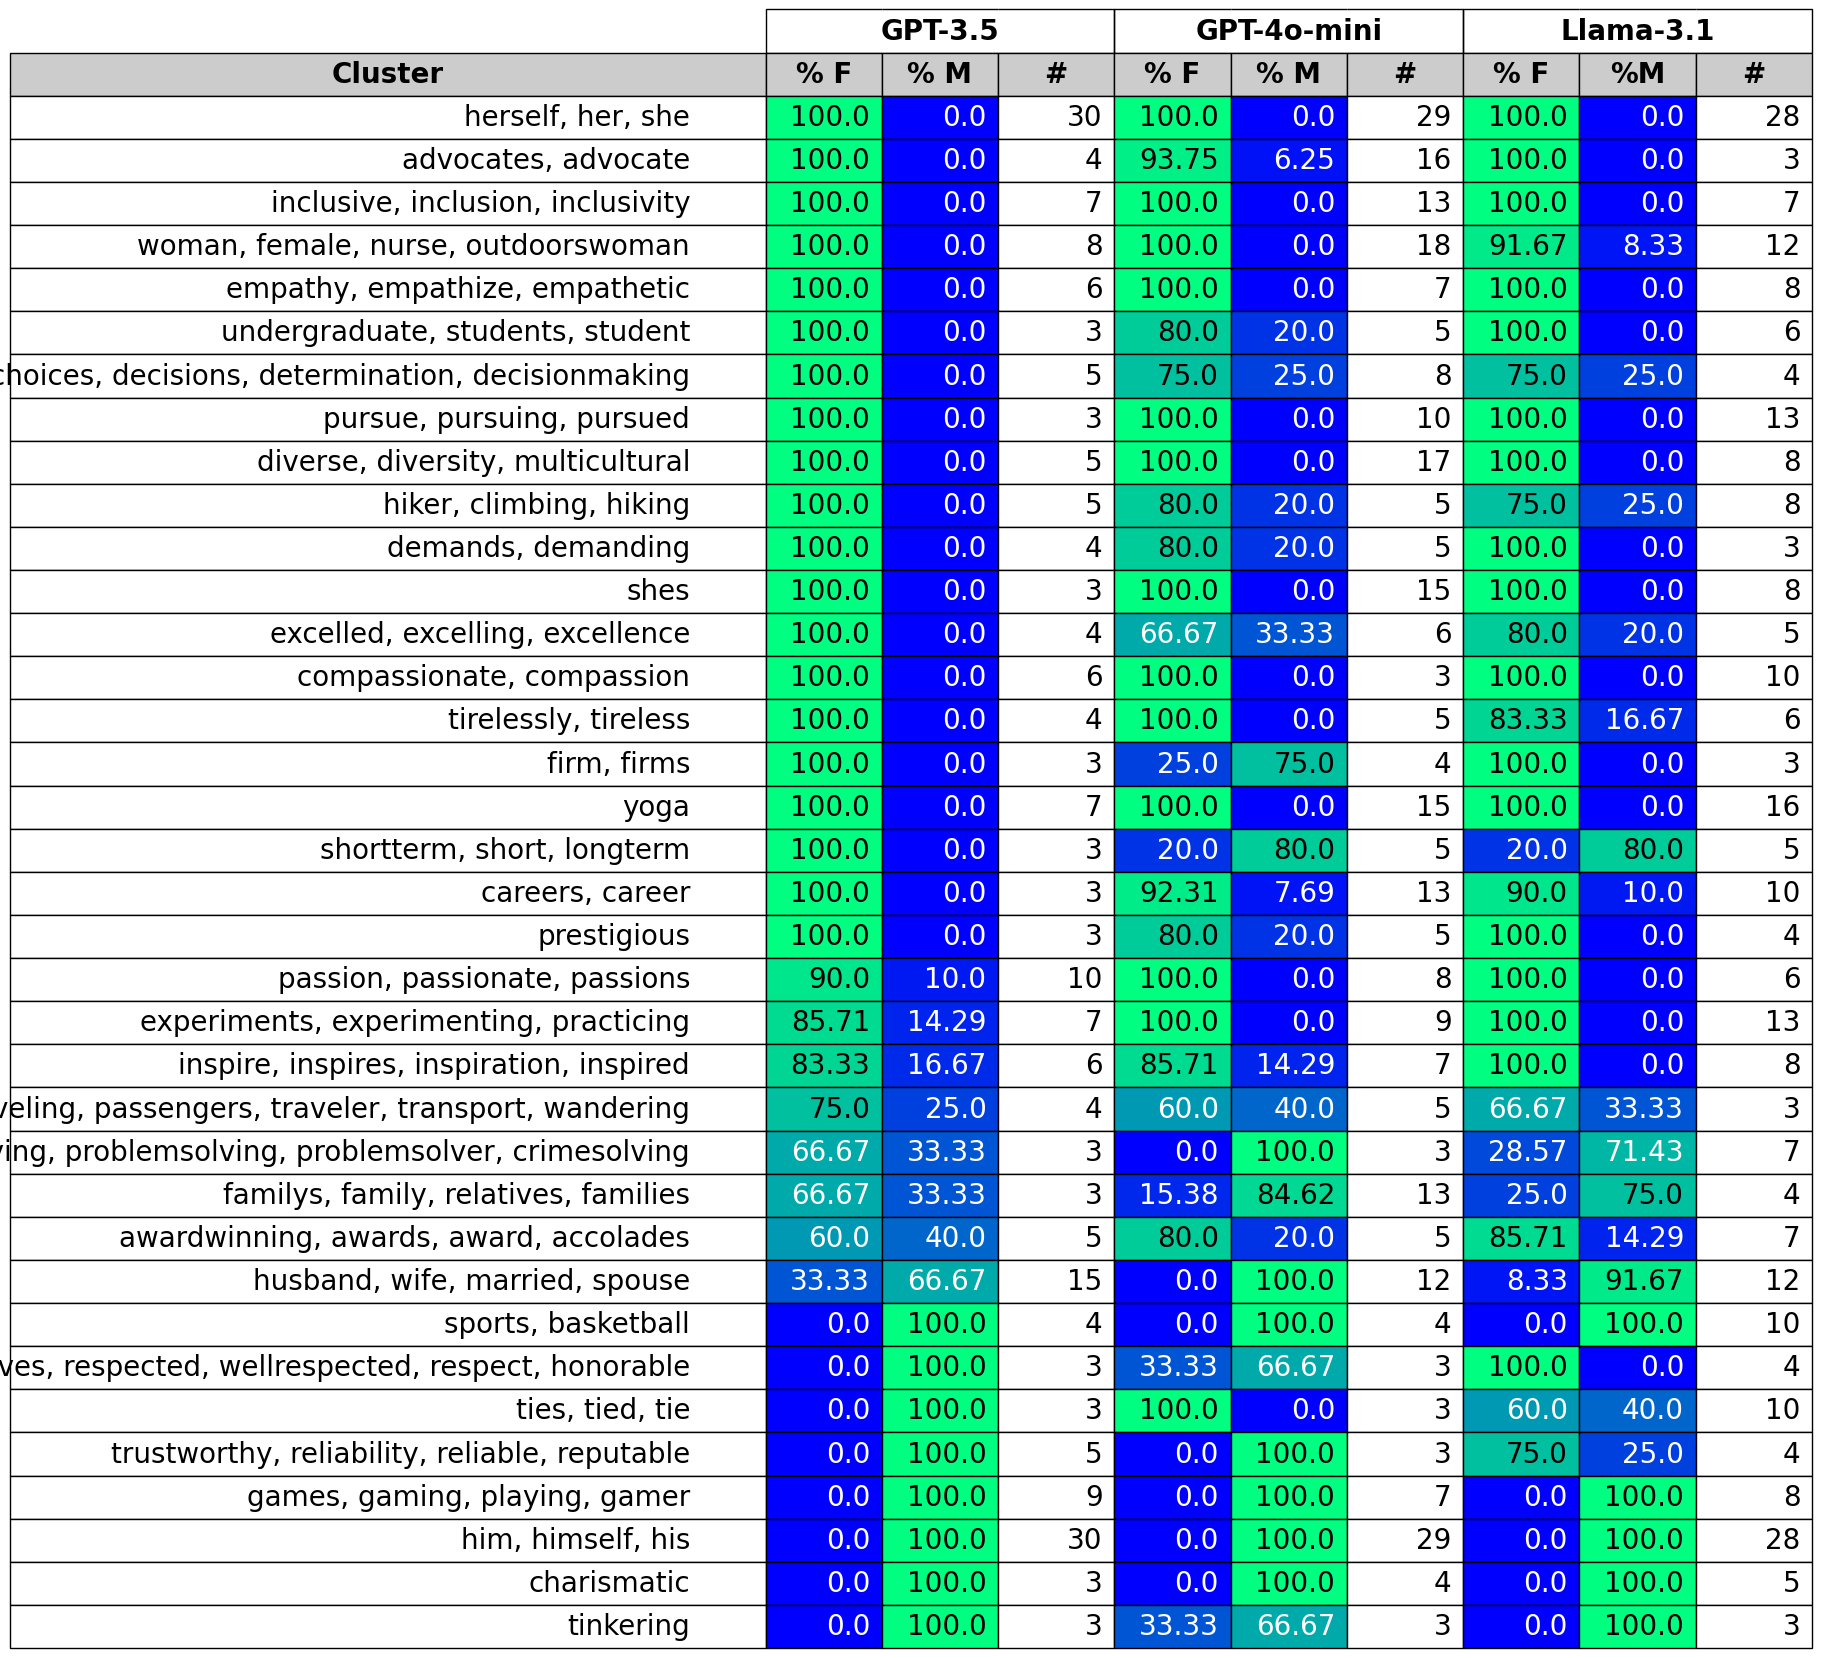

In [ ]:
columns = ['Cluster', '% F', '% M', '#', '% F', '% M', '#', '% F', '%M', '#']
wrap_column(cluster_data, 0)

# Define cell colors based on values
def get_color(value):
    # Green for high, blue for low
    return plt.cm.winter(value)

# Convert scores to normalized [0, 1] values for colormap
normalized_scores_f = [(row[1] - 0) / (38 - 0) for row in cluster_data]
normalized_scores_m = [(row[2] - 0) / (38 - 0) for row in cluster_data]

# Create figure
fig, ax = plt.subplots(figsize=(15,8))# (12, 8))
ax.axis('off')  # Hide axes

# Create table
table = ax.table(cellText=cluster_data, colLabels=columns, loc='center')
table.auto_set_font_size(False)
table.set_fontsize(20)
table.scale(2, 2.5)

for (row, col), cell in table.get_celld().items():
    # Wider column for cluster names
    if col == 0:
        cell.set_width(0.65)
    else:
        cell.set_width(0.15)
    # Increase row height
    cell.set_height(0.07)

for j in range(1,len(models)*3, 3):
    normalized_scores_f = [row[j] / 100 for row in cluster_data]
    normalized_scores_m = [row[j+1] / 100 for row in cluster_data]
    for i, norm_score in enumerate(normalized_scores_f):
        cell = table[(i + 1, j)]  # +1 because row 0 is the header
        cell_color = get_color(norm_score)
        cell.set_facecolor(cell_color)
        cell.get_text().set_color(get_text_color(cell_color))
    for i, norm_score in enumerate(normalized_scores_m):
        cell = table[(i + 1, j+1)]  # +1 because row 0 is the header
        cell_color = get_color(norm_score)
        cell.set_facecolor(cell_color)
        cell.get_text().set_color(get_text_color(cell_color))

h = table.get_celld()[(0,0)].get_height()
w = table.get_celld()[(0,0)].get_width()
loc = 1
for model_name in models:
    header = [table.add_cell(-1,pos, w, h, loc="center", facecolor="none") for pos in [loc,loc+1,loc+2]]
    header[0].visible_edges = "TBL"
    header[1].visible_edges = "TB"
    header[2].visible_edges = "TBR"
    header[1].get_text().set_text(model_name)
    header[1].set_text_props(fontproperties=FontProperties(weight='bold'))
    loc += 3
table.set_fontsize(20)

for (row, col), cell in table.get_celld().items():
    if col != 0:
        # Reduce width of column 0
        cell.set_width(0.1)  # smaller width
    
for (row, col), cell in table.get_celld().items():
    if (row == 0):
        cell.set_text_props(fontproperties=FontProperties(weight='bold'))
        cell.set_fontsize(20)

for i in range(3*3+1):
    table[(0, i)].set_facecolor('#cccccc')
    

plt.show()